In [145]:
import pandas as pd
import numpy as np
import os
import math

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from scipy.stats import pearsonr
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

import geopandas as gpd
from shapely.geometry import Point
from geopandas import GeoDataFrame
from geopy.distance import geodesic
from datetime import date, timedelta

from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from datetime import date, timedelta
from collections import defaultdict

from scipy.stats import genextreme
import warnings

warnings.filterwarnings('ignore')

## Load Datasets

Loads the core gridMET weather table and county-level corn yield labels used throughout the notebook.


In [147]:
gridmet_data = pd.read_csv("/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/gridMET.csv")
yield_data = pd.read_csv("/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/original/label_1980_2018_rawyield.csv")

In [148]:
gridmet_data.columns

Index(['id2', 'year', 'yield', 'tmmx-10-04', 'tmmx-11-04', 'tmmx-12-04',
       'tmmx-13-04', 'tmmx-14-04', 'tmmx-15-04', 'tmmx-16-04',
       ...
       'th-27-10', 'th-28-10', 'th-29-10', 'th-30-10', 'th-31-10', 'th-01-11',
       'th-02-11', 'th-03-11', 'th-04-11', 'th-05-11'],
      dtype='object', length=3363)

### Average Corn Yield Over the Years

Computes year-wise mean yield and plots the long-term corn yield trend to establish temporal baseline behavior.


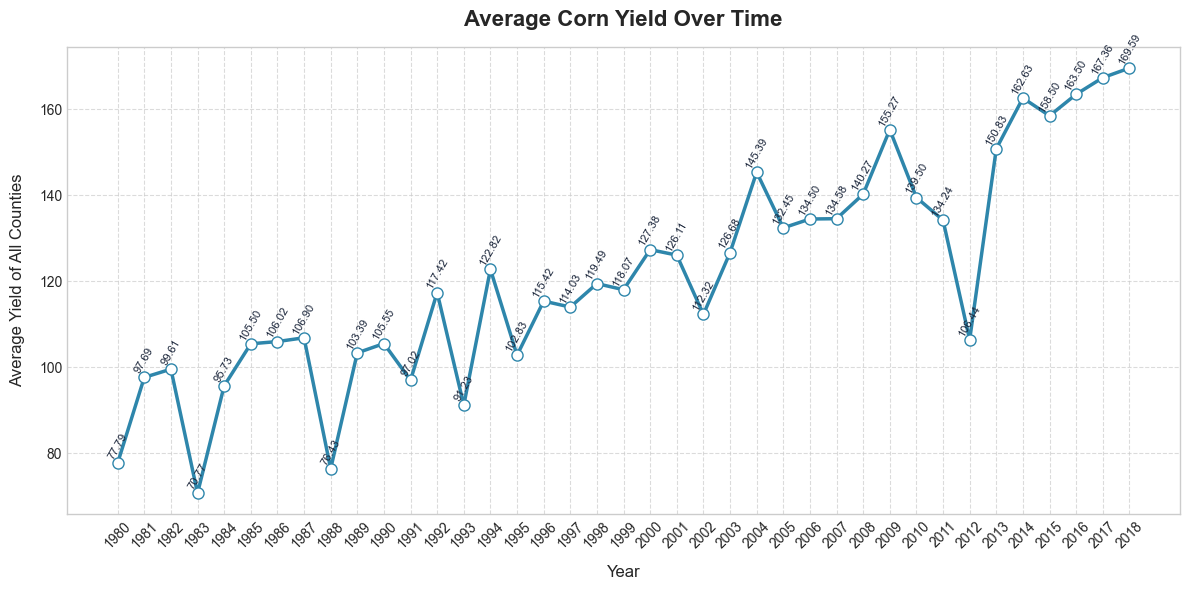

In [110]:
import matplotlib.pyplot as plt

yearly_avg_yield = yield_data.groupby('year')['yield'].mean()

plt.style.use("seaborn-v0_8-whitegrid")  
plt.figure(figsize=(12, 6))

plt.plot(yearly_avg_yield.index, yearly_avg_yield.values,
         marker='o', markersize=8, linewidth=2.5, color="#2E86AB", markerfacecolor="white")

plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Average Yield of All Counties', fontsize=12, labelpad=10)
plt.title('Average Corn Yield Over Time', fontsize=16, fontweight="bold", pad=15)

plt.xticks(ticks=yearly_avg_yield.index, rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.grid(True, linestyle="--", alpha=0.7)

# annotate each point with offset & rotation
for year, avg_yield in zip(yearly_avg_yield.index, yearly_avg_yield.values):
    plt.text(year, avg_yield + 0.5, f"{avg_yield:.2f}",
             ha='center', va='bottom', fontsize = 8, rotation=60, color="#1B263B")

plt.tight_layout()
plt.show()

In [158]:
from collections import defaultdict

def create_gridmet_rolling_features(gridmet_data, variables, windows, id_cols=['id2', 'year', 'yield']):
    df = gridmet_data.copy()
    
    # Collect columns by variable and month
    var_month_cols = defaultdict(lambda: defaultdict(list))
    
    for col in df.columns:
        for var in variables:
            if col.startswith(var + "-"):
                parts = col.split('-')
                if len(parts) >= 3:
                    day = int(parts[1])
                    month = int(parts[2])
                    var_month_cols[var][month].append(col)
    
    # Extract summary stats per window
    def extract_summary_stats(sub_df, prefix):
        stats = pd.DataFrame(index=sub_df.index)
        stats[f'{prefix}_mean'] = sub_df.mean(axis=1)
        stats[f'{prefix}_std'] = sub_df.std(axis=1)
        stats[f'{prefix}_min'] = sub_df.min(axis=1)
        stats[f'{prefix}_max'] = sub_df.max(axis=1)
        stats[f'{prefix}_25q'] = sub_df.quantile(0.25, axis=1)
        stats[f'{prefix}_50q'] = sub_df.quantile(0.50, axis=1)
        stats[f'{prefix}_75q'] = sub_df.quantile(0.75, axis=1)
        stats[f'{prefix}_skew'] = sub_df.skew(axis=1)
        stats[f'{prefix}_kurt'] = sub_df.kurt(axis=1)
        return stats
    
    feature_stats_list = []
    for var in variables:
        for win_name, months in windows:
            cols_to_use = []
            for m in months:
                cols_to_use.extend(var_month_cols[var].get(m, []))
            if cols_to_use:
                stats = extract_summary_stats(df[cols_to_use], f"{var}_{win_name}")
                feature_stats_list.append(stats)
    
    features_reduced = pd.concat(feature_stats_list, axis=1)
    
    # Yield history features 
    df_yield = df[['id2', 'year', 'yield']].sort_values(['id2', 'year'])
    df_yield['yield_prev_year'] = df_yield.groupby('id2')['yield'].shift(1)
    df_yield['yield_5yr_mean'] = df_yield.groupby('id2')['yield'].shift(1).rolling(5, min_periods=1).mean().reset_index(0, drop=True)
    df_yield['yield_min'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().min())
    df_yield['yield_max'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().max())
    df_yield['yield_std'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().std())
    df_yield['yield_mean'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().mean())
    
    def add_yield_trend(group):
        proj = []
        for _, row in group.iterrows():
            past = group[group['year'] < row['year']]
            if len(past) >= 3:
                slope, intercept = np.polyfit(past['year'], past['yield'], 1)
                proj.append(slope * row['year'] + intercept)
            else:
                proj.append(np.nan)
        group['yield_trend_pred'] = proj
        return group
    
    df_yield = df_yield.groupby('id2', group_keys=False).apply(add_yield_trend)
    
    features_reduced['id2'] = df['id2']
    features_reduced['year'] = df['year']
    features_reduced['yield'] = df['yield']
    
    gridmet_aug = features_reduced.merge(df_yield.drop(columns='yield'), on=['id2', 'year'], how='left')
    
    # Rearrange
    col_list = gridmet_aug.columns
    new_order = ['id2', 'year'] + [c for c in col_list if c not in ['id2', 'year', 'yield']] + ['yield']
    gridmet_aug = gridmet_aug[new_order]
    gridmet_aug = gridmet_aug.dropna().reset_index(drop=True)
    
    return gridmet_aug

def create_gridmet_annual_features(gridmet_data, variables, id_cols=['id2', 'year', 'yield']):
    df = gridmet_data.copy()
    ts_cols = [col for col in df.columns if col not in id_cols]
    
    grouped_features = defaultdict(list)
    for col in ts_cols:
        for var in variables:
            if col.startswith(var + '-'):
                grouped_features[var].append(col)
    
    def extract_summary_stats(sub_df, prefix):
        stats = pd.DataFrame(index=sub_df.index)
        stats[f'{prefix}_mean'] = sub_df.mean(axis=1)
        # stats[f'{prefix}_std'] = sub_df.std(axis=1)
        # stats[f'{prefix}_min'] = sub_df.min(axis=1)
        # stats[f'{prefix}_max'] = sub_df.max(axis=1)
        # stats[f'{prefix}_25q'] = sub_df.quantile(0.25, axis=1)
        # stats[f'{prefix}_50q'] = sub_df.quantile(0.50, axis=1)
        # stats[f'{prefix}_75q'] = sub_df.quantile(0.75, axis=1)
        # stats[f'{prefix}_skew'] = sub_df.skew(axis=1)
        # stats[f'{prefix}_kurt'] = sub_df.kurt(axis=1)
        return stats
    
    feature_stats_list = []
    for var, cols in grouped_features.items():
        if cols:
            stats = extract_summary_stats(df[cols], var)
            feature_stats_list.append(stats)
    
    features_reduced = pd.concat(feature_stats_list, axis=1)
    
    features_reduced['id2'] = df['id2']
    features_reduced['year'] = df['year']
    features_reduced['yield'] = df['yield']
    
    df_yield = df[['id2', 'year', 'yield']].sort_values(['id2', 'year'])
    df_yield['yield_prev_year'] = df_yield.groupby('id2')['yield'].shift(1)
    df_yield['yield_5yr_mean'] = df_yield.groupby('id2')['yield'].shift(1).rolling(5, min_periods=1).mean().reset_index(0, drop=True)
    df_yield['yield_min'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().min())
    df_yield['yield_max'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().max())
    df_yield['yield_std'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().std())
    df_yield['yield_mean'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().mean())
    
    def add_yield_trend(group):
        proj = []
        for _, row in group.iterrows():
            past = group[group['year'] < row['year']]
            if len(past) >= 3:
                slope, intercept = np.polyfit(past['year'], past['yield'], 1)
                proj.append(slope * row['year'] + intercept)
            else:
                proj.append(np.nan)
        group['yield_trend_pred'] = proj
        return group
    
    df_yield = df_yield.groupby('id2', group_keys=False).apply(add_yield_trend)
    
    gridmet_aug = features_reduced.merge(df_yield.drop(columns='yield'), on=['id2', 'year'], how='left')
    
    # Rearrange columns
    col_list = gridmet_aug.columns
    new_order = ['id2', 'year'] + [c for c in col_list if c not in ['id2', 'year', 'yield']] + ['yield']
    gridmet_aug = gridmet_aug[new_order]
    gridmet_aug = gridmet_aug.dropna().reset_index(drop=True)
    
    return gridmet_aug

In [159]:
# def add_gdd_kdd(df):
#     T_BASE = 10        # GDD base temperature for maize
#     T_CEILING = 30     # GDD cap temperature
#     T_CRITICAL = 29    # KDD threshold for maize

#     for col in df.columns:
#         if col.startswith("tmmx-"):

#             # Do NOT convert to integers — keep original text
#             _, day, month = col.split("-")

#             tmax = df[f"tmmx-{day}-{month}"]
#             tmin = df[f"tmmn-{day}-{month}"]

#             # --- GDD ---
#             tmean = (tmax + tmin) / 2
#             tmean_capped = np.clip(tmean, T_BASE, T_CEILING)
#             GDD = (tmean_capped - T_BASE).clip(lower=0)

#             df[f"GDD-{day}-{month}"] = GDD

#             # --- KDD ---
#             KDD = (tmax - T_CRITICAL).clip(lower=0)

#             df[f"KDD-{day}-{month}"] = KDD

#     return df


# variables = ['GDD', 'KDD',
#              'tmmn', 'tmmx', 'pr', 'srad', 'sph', 'rmin',
#              'rmax', 'vs', 'th', 'vpd', 'pet', 'etr', 
#              'erc', 'bi', 'fm100', 'fm1000']

# variables = ['GDD', 'KDD']

# gridmet_data = add_gdd_kdd(gridmet_data)

variables = ['tmmn', 'tmmx', 'pr', 'srad', 'sph', 'rmin', 'rmax', 'vs',
             'th', 'vpd', 'pet', 'etr', 'erc', 'bi', 'fm100', 'fm1000']

# variables = ['tmmn', 'tmmx', 'pr', 'srad', 'sph', 'rmin', 'rmax', 'vs',
#              'th', 'vpd']


# variables = ['vpd', 'bi', 'etr'] ## 'fm100', 'fm1000'

# variables = ['vpd', 'etr'] ## 'fm100', 'fm1000', 'sph', 


windows = [
        ('AMJ', [4, 5, 6]),
        ('MJJ', [5, 6, 7]),
        ('JJA', [6, 7, 8]),
        ('JAS', [7, 8, 9]),
        ('ASO', [8, 9, 10])]

# windows = [
#         ('AMJ', [4, 5, 6]),
#         ('MJJ', [5, 6, 7]),
#         ('JJA', [6, 7, 8]),
#         ('JAS', [7, 8, 9])]      

id_cols=['id2', 'year', 'yield']

## To create rolling 3-month features
# gridmet_aug = create_gridmet_rolling_features(gridmet_data, variables, windows, id_cols)
# gridmet_aug = gridmet_aug[gridmet_aug['id2'] != 3066] ## Remove 3066 county

# ## To create annual features
gridmet_aug = create_gridmet_annual_features(gridmet_data, variables)
gridmet_aug = gridmet_aug[gridmet_aug['id2'] != 3066]

In [160]:
## Check if the errorneous county was removed
if 3066 in gridmet_aug['id2'].values:
    print("County exist")
else:
    print("County doesn't exist")

County doesn't exist


In [161]:
gridmet_aug

,id2,year,tmmx_mean,rmax_mean,vs_mean,bi_mean,sph_mean,fm1000_mean,srad_mean,erc_mean,...,tmmn_mean,th_mean,yield_prev_year,yield_5yr_mean,yield_min,yield_max,yield_std,yield_mean,yield_trend_pred,yield
0,112,1983,300.639303,94.097118,3.815043,16.742324,0.010995,18.575281,237.410359,23.975018,...,286.973014,179.288948,73.0,85.20,27.0,73.0,24.193663,54.333333,100.333333,60.0
1,119,1983,302.029915,93.633880,3.329415,16.203583,0.011223,17.760443,235.748185,26.791561,...,288.333050,173.578359,114.0,88.20,29.0,114.0,42.852460,74.666667,159.666667,93.0
2,120,1983,301.208597,93.061567,3.651784,15.083636,0.010881,18.147775,234.792130,24.919567,...,287.389697,190.374372,90.0,95.00,28.0,90.0,31.432467,56.000000,118.000000,43.0
3,124,1983,302.114678,92.225551,3.264911,16.708450,0.011364,17.480686,236.101303,27.773810,...,289.102773,176.311718,86.0,96.80,24.0,86.0,34.443190,63.666667,125.666667,72.0
4,136,1983,302.057880,93.499875,3.533090,16.377721,0.011257,17.874337,236.271565,26.480215,...,288.533186,176.063265,80.0,96.00,24.0,80.0,30.746273,59.333333,115.333333,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41262,3121,2018,294.953877,95.237614,4.204021,13.405676,0.009771,21.211203,220.000207,16.774844,...,283.506739,174.472102,181.5,125.94,53.3,181.5,27.612252,124.876316,160.210384,182.0
41263,3122,2018,294.790673,93.421281,4.147997,16.808169,0.009020,19.395304,217.519544,21.958785,...,282.975300,182.414943,165.7,127.86,74.1,165.7,21.031809,121.163158,152.408819,156.8
41264,3123,2018,294.716057,92.840480,4.182206,15.581997,0.009125,19.702084,215.686358,20.906475,...,283.231696,181.480117,161.5,129.76,78.2,182.8,24.703348,124.039474,157.790327,163.4
41265,3124,2018,294.695984,90.952795,4.101506,16.745551,0.009123,18.975743,218.553170,22.901587,...,283.858971,179.765945,164.0,131.56,62.1,164.0,23.261209,119.194595,149.548583,160.4


Reference samples (1980–2011): 38373
Monitored samples (2012):      1086
Total samples used:            39459

Domain-classifier AUROC (5-fold CV):
Scores: [0.964  0.9702 0.9613 0.9689 0.9697]
Mean AUROC: 0.9668  |  Std: 0.0035


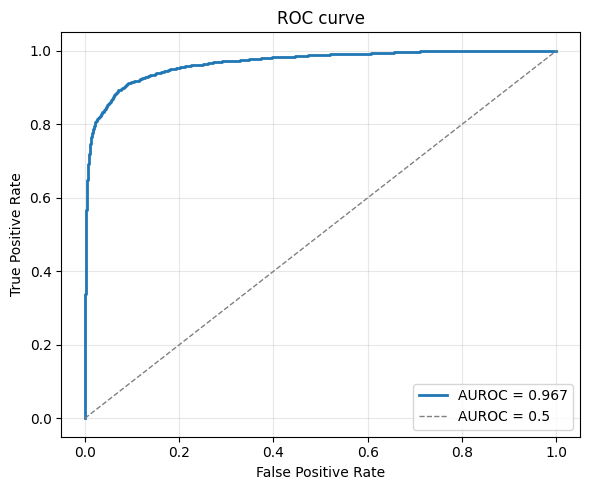


Interpretation: Strong evidence of covariate shift (2012 differs substantially in joint feature space).


In [16]:
# Domain Classifier test for multivariate covariate shift + ROC/AUROC plot
# Dataset: gridmet_aug
# Train domain = years 1980–2011 (label 0), Test domain = year 2012 (label 1)
# Uses only meteorological features (drops yield + year + id2)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# --- 1) Define feature columns (meteorology only) ---
met_cols = [
    'vpd_AMJ_mean', 'vpd_MJJ_mean', 'vpd_JJA_mean', 'vpd_JAS_mean', 'vpd_ASO_mean',
    'etr_AMJ_mean', 'etr_MJJ_mean', 'etr_JJA_mean', 'etr_JAS_mean', 'etr_ASO_mean'
]

# --- 2) Build domain-labeled dataset ---
df = gridmet_aug.copy()

ref = df[(df['year'] >= 1980) & (df['year'] <= 2011)].copy()
mon = df[df['year'] == 2012].copy()

# Keep only needed columns and drop rows with missing met features
ref = ref[['id2', 'year'] + met_cols].dropna()
mon = mon[['id2', 'year'] + met_cols].dropna()

X = pd.concat([ref[met_cols], mon[met_cols]], axis=0)
y = np.concatenate([np.zeros(len(ref), dtype=int), np.ones(len(mon), dtype=int)])

print(f"Reference samples (1980–2011): {len(ref)}")
print(f"Monitored samples (2012):      {len(mon)}")
print(f"Total samples used:            {len(y)}")

# --- 3) Domain classifier ---
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",   # helps if 2012 has fewer samples
        solver="lbfgs"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# (A) Numeric AUROC via CV (what you already have)
auc_scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")
print("\nDomain-classifier AUROC (5-fold CV):")
print("Scores:", np.round(auc_scores, 4))
print(f"Mean AUROC: {auc_scores.mean():.4f}  |  Std: {auc_scores.std():.4f}")

# (B) OUT-OF-FOLD probabilities for ROC curve (key change)
# cross_val_predict gives out-of-fold predictions -> honest ROC curve
y_scores = cross_val_predict(
    clf, X, y,
    cv=cv,
    method="predict_proba"
)[:, 1]   # probability of class 1 (2012)

# ROC curve + AUROC
fpr, tpr, _ = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

# --- 4) Plot ROC curve (visual AUROC) ---
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"AUROC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", lw=1, color="gray", label="AUROC = 0.5")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "Figures/domain_classifier_roc_2012.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# --- 5) Simple interpretation ---
mean_auc = auc_scores.mean()
if mean_auc < 0.55:
    verdict = "No / weak evidence of covariate shift (train vs 2012 hard to distinguish)."
elif mean_auc < 0.70:
    verdict = "Moderate evidence of covariate shift."
else:
    verdict = "Strong evidence of covariate shift (2012 differs substantially in joint feature space)."

print("\nInterpretation:", verdict)

## Lasso (80:20)

Builds a random 80/20 split within a selected year, standardizes features, fits Lasso with CV tuning, and reports test-set error metrics plus scatter diagnostics.


In [170]:
non_model_cols = ['yield']

data_2012 = gridmet_aug[gridmet_aug['year'] == 2013]

### Drop year column
data_2012.drop(columns = ['year'], axis=1, inplace=True)

train_data, test_data = train_test_split(
    data_2012,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

X_train = train_data.drop(columns=non_model_cols)
y_train = train_data['yield']
X_test = test_data.drop(columns=non_model_cols)
y_test = test_data['yield']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso_model = Lasso(alpha=0.5)

cv_scores = cross_val_score(
    lasso_model,
    X_train_scaled,
    y_train,
    cv=20,
    scoring='r2'
)

lasso_model.fit(X_train_scaled, y_train)
y_pred = lasso_model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
y_test_mean = np.mean(y_test)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - y_test_mean) ** 2)
r2_verify = 1 - (ssr / sst)

pearson_r, _ = pearsonr(y_test, y_pred)
pearson_r2 = pearson_r**2

mean_true = np.mean(y_test)
mean_pred = np.mean(y_pred)
deviations_true = y_test - mean_true
deviations_pred = y_pred - mean_pred
numerator = np.sum(deviations_true * deviations_pred)
denominator = np.sqrt(np.sum(deviations_true ** 2) * np.sum(deviations_pred ** 2))
pearson_r_verify = numerator / denominator
pearson_r2_verify = pearson_r_verify ** 2

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

mean_pred = np.mean(y_pred)
bias = mean_pred - mean_true
bias_squared = bias ** 2
# variance = np.mean((y_pred - y_test) ** 2)
residuals = y_test - y_pred
mean_residual = np.mean(residuals)
variance = np.mean((residuals - mean_residual) ** 2)
std_dev = np.sqrt(variance)
mse_verify = bias_squared + variance
rmse_verify = np.sqrt(mse_verify)

print(f"  R2: {r2:.4f}")
print(f"  R2 Verified: {r2_verify:.4f}")
print(f"  Pearson R2: {pearson_r2:.4f}")
print(f"  Pearson R2 Verified: {pearson_r2_verify:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  Bias: {bias:.4f}")
print(f"  Bias²: {bias_squared:.4f}")
print(f"  Variance: {variance:.4f}")
print(f"  Std Dev: {std_dev:.4f}")
print(f"  MSE Verified: {mse_verify:.4f}")
print(f"  RMSE Verified: {rmse_verify:.4f}")


# -------------------------------------------------------------------
# County-level error distribution (1 prediction per county)
# -------------------------------------------------------------------

errors = residuals.to_numpy() if hasattr(residuals, "to_numpy") else residuals
N = len(errors)

rmse_from_errors = np.sqrt(np.mean(errors**2))
std_error = np.std(errors, ddof=1)

se_bias = std_error / np.sqrt(N)          
se_rmse = std_error / np.sqrt(2 * N)      

print("\n--- RMSE + CLT uncertainty ---")
print(f"  RMSE (from errors): {rmse_from_errors:.4f}")
print(f"  Error std dev:      {std_error:.4f}")
print(f"  SE(Bias) (CLT):     {se_bias:.4f}")
print(f"  SE(RMSE) (CLT):     {se_rmse:.4f}")
print(f"  N counties:         {N}")

  R2: 0.7027
  R2 Verified: 0.7027
  Pearson R2: 0.7043
  Pearson R2 Verified: 0.7043
  RMSE: 18.2400
  MAE: 13.8229
  Bias: 0.4179
  Bias²: 0.1746
  Variance: 332.5222
  Std Dev: 18.2352
  MSE Verified: 332.6968
  RMSE Verified: 18.2400

--- RMSE + CLT uncertainty ---
  RMSE (from errors): 18.2400
  Error std dev:      18.2812
  SE(Bias) (CLT):     1.2959
  SE(RMSE) (CLT):     0.9164
  N counties:         199


## Lasso (80:20) (2013)

Repeats the within-year 80/20 Lasso pipeline for the 2013 setup to compare fit quality and error spread against the previous split.


In [87]:
non_model_cols = ['yield']

data_2012 = gridmet_aug[gridmet_aug['year'] == 2013]

### Drop year column
data_2012.drop(columns = ['year'], axis=1, inplace=True)

train_data, test_data = train_test_split(
    data_2012,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

X_train = train_data.drop(columns=non_model_cols)
y_train = train_data['yield']
X_test = test_data.drop(columns=non_model_cols)
y_test = test_data['yield']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso_model = Lasso(alpha=0.05)

cv_scores = cross_val_score(
    lasso_model,
    X_train_scaled,
    y_train,
    cv=20,
    scoring='r2'
)

lasso_model.fit(X_train_scaled, y_train)
y_pred = lasso_model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
y_test_mean = np.mean(y_test)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - y_test_mean) ** 2)
r2_verify = 1 - (ssr / sst)

pearson_r, _ = pearsonr(y_test, y_pred)
pearson_r2 = pearson_r**2

mean_true = np.mean(y_test)
mean_pred = np.mean(y_pred)
deviations_true = y_test - mean_true
deviations_pred = y_pred - mean_pred
numerator = np.sum(deviations_true * deviations_pred)
denominator = np.sqrt(np.sum(deviations_true ** 2) * np.sum(deviations_pred ** 2))
pearson_r_verify = numerator / denominator
pearson_r2_verify = pearson_r_verify ** 2

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

mean_pred = np.mean(y_pred)
bias = mean_pred - mean_true
bias_squared = bias ** 2
# variance = np.mean((y_pred - y_test) ** 2)
residuals = y_test - y_pred
mean_residual = np.mean(residuals)
variance = np.mean((residuals - mean_residual) ** 2)
std_dev = np.sqrt(variance)
mse_verify = bias_squared + variance
rmse_verify = np.sqrt(mse_verify)

print(f"  R2: {r2:.4f}")
print(f"  R2 Verified: {r2_verify:.4f}")
4print(f"  Pearson R2: {pearson_r2:.4f}")
print(f"  Pearson R2 Verified: {pearson_r2_verify:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  Bias: {bias:.4f}")
print(f"  Bias²: {bias_squared:.4f}")
print(f"  Variance: {variance:.4f}")
print(f"  Std Dev: {std_dev:.4f}")
print(f"  MSE Verified: {mse_verify:.4f}")
print(f"  RMSE Verified: {rmse_verify:.4f}")

  R2: 0.8044
  R2 Verified: 0.8044
  Pearson R2: 0.8056
  Pearson R2 Verified: 0.8056
  RMSE: 14.7941
  MAE: 11.0090
  Bias: -0.9862
  Bias²: 0.9726
  Variance: 217.8924
  Std Dev: 14.7612
  MSE Verified: 218.8650
  RMSE Verified: 14.7941


## Lasso (Train: All previous, Test: 2012)

Trains Lasso on earlier years and evaluates on a held-out temporal block, measuring generalization under a chronological split rather than random sampling.


In [165]:
non_model_cols = ['yield']

train_data = gridmet_aug[gridmet_aug['year'] < 2012]
test_data = gridmet_aug[gridmet_aug['year'] == 2012]

### Drop year column
# train_data.drop(columns = ['year'], axis=1, inplace=True)
# test_data.drop(columns = ['year'], axis=1, inplace=True)

train_data = gridmet_aug[gridmet_aug['year'] < 2007]
test_data = gridmet_aug[(gridmet_aug['year'] >= 2007) & (gridmet_aug['year'] <= 2011)]

### Drop year column
train_data.drop(columns = ['year'], axis=1, inplace=True)
test_data.drop(columns = ['year'], axis=1, inplace=True)


X_train = train_data.drop(columns=non_model_cols)
y_train = train_data['yield']
X_test = test_data.drop(columns=non_model_cols)
y_test = test_data['yield']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lasso = Lasso(alpha=0.1)

cv_scores = cross_val_score(
    model_lasso, 
    X_train_scaled, 
    y_train, 
    cv=20, 
    scoring='r2'
)
# print("[Validation] Mean CV scores", cv_scores.mean())
# print("[Validation] Mean CV std", cv_scores.std())

model_lasso.fit(X_train_scaled, y_train)
y_pred = model_lasso.predict(X_test_scaled)

## R2 Score
## Using pre-defined function
r2 = r2_score(y_test, y_pred)
## Manually
y_test_mean = np.mean(y_test)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - y_test_mean) ** 2)
r2_verify = 1 - (ssr / sst)

## Pearson R2
## Using pre-defined function
pearson_r, _ = pearsonr(y_test, y_pred)
pearson_r2 = pearson_r**2
## Manually
mean_true = np.mean(y_test)
mean_pred = np.mean(y_pred)
deviations_true = y_test - mean_true
deviations_pred = y_pred - mean_pred
numerator = np.sum(deviations_true * deviations_pred)
denominator = np.sqrt(np.sum(deviations_true ** 2) * np.sum(deviations_pred ** 2))
pearson_r_verify = numerator/denominator
pearson_r2_verify = pearson_r_verify ** 2

## RMSE
## Using pre-defined function
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
## Manually
mean_pred = np.mean(y_pred)
mean_true = np.mean(y_test)
bias = mean_pred - mean_true
bias_squared = bias ** 2
# variance = np.mean((y_pred - mean_pred) ** 2)
residuals = y_test - y_pred
mean_residual = np.mean(residuals)
variance = np.mean((residuals - mean_residual) ** 2)
std_dev = np.sqrt(variance)  
mse_verify = bias_squared + variance
rmse_verify = np.sqrt(mse_verify)

print(f"  R2: {r2:.4f}")
print(f"  R2 Verified: {r2_verify:.4f}")
print(f"  Pearson R2: {pearson_r2:.4f}")
print(f"  Pearson R2 Verified: {pearson_r2_verify:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  Bias: {bias:.4f}")
print(f"  Bias²: {bias_squared:.4f}")
print(f"  Variance: {variance:.4f}")
print(f"  Std Dev: {std_dev:.4f}")  
print(f"  MSE Verifed: {mse_verify:.4f}")
print(f"  RMSE Verifed: {rmse_verify:.4f}")

# -------------------------------------------------------------------
# County-level error distribution (1 prediction per county)
# -------------------------------------------------------------------

errors = (y_test - y_pred).to_numpy() if hasattr(y_test, "to_numpy") else (y_test - y_pred)
N = len(errors)

rmse = np.sqrt(np.mean(errors**2))
var_error = np.var(errors, ddof=1)
std_error = np.sqrt(var_error)

mean_error = errors.mean()
se_mean_error = std_error / np.sqrt(N)
se_rmse = std_error / np.sqrt(2 * N)   

print("\n--- RMSE summary ---")
print(f"RMSE: {rmse:.2f}")
print(f"Error variance: {var_error:.2f}")
print(f"Error std dev: {std_error:.2f}")

print("\n--- CLT uncertainty ---")
print(f"Mean error (bias): {mean_error:.2f} ± {se_mean_error:.2f}")
print(f"RMSE uncertainty (CLT approx): ±{se_rmse:.2f}")
print(f"N counties: {N}")

  R2: 0.5780
  R2 Verified: 0.5780
  Pearson R2: 0.6409
  Pearson R2 Verified: 0.6409
  RMSE: 20.5093
  Bias: -7.7688
  Bias²: 60.3539
  Variance: 360.2756
  Std Dev: 18.9809
  MSE Verifed: 420.6294
  RMSE Verifed: 20.5093

--- RMSE summary ---
RMSE: 20.51
Error variance: 360.34
Error std dev: 18.98

--- CLT uncertainty ---
Mean error (bias): 7.77 ± 0.26
RMSE uncertainty (CLT approx): ±0.18
N counties: 5389


## Lasso (Train: All previous, Test: 2013)

Runs the same temporal-transfer Lasso workflow with a shifted train/test year window targeting 2013-style out-of-time prediction.


In [168]:
non_model_cols = ['yield']

# train_data = gridmet_aug[gridmet_aug['year'] < 2013]
# test_data = gridmet_aug[gridmet_aug['year'] == 2013]

train_data = gridmet_aug[gridmet_aug['year'] < 2008]
test_data = gridmet_aug[(gridmet_aug['year'] >= 2008) & (gridmet_aug['year'] <= 2012)]

### Drop year column
train_data.drop(columns = ['year'], axis=1, inplace=True)
test_data.drop(columns = ['year'], axis=1, inplace=True)


X_train = train_data.drop(columns=non_model_cols)
y_train = train_data['yield']
X_test = test_data.drop(columns=non_model_cols)
y_test = test_data['yield']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lasso = Lasso(alpha=0.05)

cv_scores = cross_val_score(
    model_lasso, 
    X_train_scaled, 
    y_train, 
    cv=20, 
    scoring='r2'
)
# print("[Validation] Mean CV scores", cv_scores.mean())
# print("[Validation] Mean CV std", cv_scores.std())

model_lasso.fit(X_train_scaled, y_train)
y_pred = model_lasso.predict(X_test_scaled)

## R2 Score
## Using pre-defined function
r2 = r2_score(y_test, y_pred)
## Manually
y_test_mean = np.mean(y_test)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - y_test_mean) ** 2)
r2_verify = 1 - (ssr / sst)

## Pearson R2
## Using pre-defined function
pearson_r, _ = pearsonr(y_test, y_pred)
pearson_r2 = pearson_r**2
## Manually
mean_true = np.mean(y_test)
mean_pred = np.mean(y_pred)
deviations_true = y_test - mean_true
deviations_pred = y_pred - mean_pred
numerator = np.sum(deviations_true * deviations_pred)
denominator = np.sqrt(np.sum(deviations_true ** 2) * np.sum(deviations_pred ** 2))
pearson_r_verify = numerator/denominator
pearson_r2_verify = pearson_r_verify ** 2

## RMSE
## Using pre-defined function
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
## Manually
mean_pred = np.mean(y_pred)
mean_true = np.mean(y_test)
bias = mean_pred - mean_true
bias_squared = bias ** 2
# variance = np.mean((y_pred - mean_pred) ** 2)
residuals = y_test - y_pred
mean_residual = np.mean(residuals)
variance = np.mean((residuals - mean_residual) ** 2)
std_dev = np.sqrt(variance)  
mse_verify = bias_squared + variance
rmse_verify = np.sqrt(mse_verify)

print(f"  R2: {r2:.4f}")
print(f"  R2 Verified: {r2_verify:.4f}")
print(f"  Pearson R2: {pearson_r2:.4f}")
print(f"  Pearson R2 Verified: {pearson_r2_verify:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  Bias: {bias:.4f}")
print(f"  Bias²: {bias_squared:.4f}")
print(f"  Variance: {variance:.4f}")
print(f"  Std Dev: {std_dev:.4f}")  
print(f"  MSE Verifed: {mse_verify:.4f}")
print(f"  RMSE Verifed: {rmse_verify:.4f}")

  R2: 0.6012
  R2 Verified: 0.6012
  Pearson R2: 0.6388
  Pearson R2 Verified: 0.6388
  RMSE: 22.8852
  Bias: -6.8889
  Bias²: 47.4570
  Variance: 476.2736
  Std Dev: 21.8237
  MSE Verifed: 523.7306
  RMSE Verifed: 22.8852


## SHAP Analysis

Uses SHAP values on the fitted model to rank feature influence and visualize which weather variables drive prediction magnitude and direction.


In [169]:
import shap

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

# 1) Drop obvious non-features (optional)
cols_to_drop = ["year", "Year", "County ID"]
X_train_tmp = X_train_scaled_df.drop(columns=[c for c in cols_to_drop if c in X_train_scaled_df.columns])
X_test_tmp  = X_test_scaled_df.drop(columns=[c for c in cols_to_drop if c in X_test_scaled_df.columns])

# 2) Keep ONLY these variables (your list)
base_name_map = {
    "tmmn": "Min Temp", "tmmx": "Max Temp", "pr": "Precip.", "srad": "Solar Rad.",
    "sph": "Spec. Humidity", "rmin": "Min RH", "rmax": "Max RH", "vs": "Wind Speed",
    "th": "Wind Dir.", "vpd": "VPD", "pet": "ET (Grass)", "etr": "ET (Alfalfa)",
    "erc": "ERC", "bi": "Burning Index", "fm100": "FM100", "fm1000": "FM1000",
}
keep_bases = set(base_name_map.keys())

def col_base(col: str) -> str:
    # works for "tmmn-AMJ_mean", "tmmn_mean", "tmmn-1", etc.
    c = col.replace("_mean", "")
    return c.split("-")[0].split("_")[0]

keep_cols = [c for c in X_test_tmp.columns if col_base(c) in keep_bases]

X_train_shap = X_train_tmp[keep_cols]
X_test_shap  = X_test_tmp[keep_cols]

# 3) IMPORTANT: model and SHAP data must match columns
# If model_lasso was fit on MORE columns, refit for SHAP on these columns:
lasso_for_shap = Lasso(alpha=model_lasso.alpha)
lasso_for_shap.fit(X_train_shap, y_train)

explainer = shap.LinearExplainer(
    lasso_for_shap,
    X_train_shap,
    feature_perturbation="interventional"
)
shap_values = explainer.shap_values(X_test_shap)

def pretty_name(col):
    return base_name_map.get(col_base(col), col)

feature_names = [pretty_name(c) for c in X_test_shap.columns]

shap.summary_plot(
    shap_values,
    X_test_shap.values,
    feature_names=feature_names,
    show=False
)

plt.gca().tick_params(axis="y", labelsize=16)
plt.gca().tick_params(axis="x", labelsize=16)
plt.xlabel("Impact on model output", fontsize=18)

fig = plt.gcf()
for ax in fig.axes:
    if ax.get_ylabel() == "Feature value":
        ax.tick_params(labelsize=14)
        ax.set_ylabel("Feature value", fontsize=16)

plt.tight_layout()
plt.savefig("Figures/paper-plots/shap_summary_2013.png", dpi=400, bbox_inches="tight")
plt.close()

In [20]:
X_test_shap.columns

Index(['County ID', 'Year', 'tmmx_mean', 'rmax_mean', 'vs_mean', 'bi_mean',
       'sph_mean', 'fm1000_mean', 'srad_mean', 'erc_mean', 'vpd_mean',
       'rmin_mean', 'pr_mean', 'fm100_mean', 'etr_mean', 'pet_mean',
       'tmmn_mean', 'th_mean', 'Prev. Yield'],
      dtype='object')

In [44]:
sample_ind = 20
shap.plots.waterfall(shap_values_2012[sample_ind], max_display=14)

TypeError: The waterfall plot requires an `Explanation` object as the `shap_values` argument.

### Ridge Regression

Fits a Ridge baseline on the same train/test year split and compares its regularized linear performance against sparse Lasso behavior.


In [79]:
non_model_cols = ['yield']

train_data = gridmet_aug[gridmet_aug['year'] < 2012]
test_data = gridmet_aug[gridmet_aug['year'] == 2012]

train_data.drop(columns = ['year'], axis=1, inplace=True)
test_data.drop(columns = ['year'], axis=1, inplace=True)

X_train = train_data.drop(columns=non_model_cols)
y_train = train_data['yield']
X_test = test_data.drop(columns=non_model_cols)
y_test = test_data['yield']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Ridge(alpha=500.0)

cv_scores = cross_val_score(
    model, 
    X_train_scaled, 
    y_train, 
    cv=20, 
    scoring='r2'
)
print("[Validation] Mean CV scores", cv_scores.mean())
print("[Validation] Mean CV std", cv_scores.std())

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
y_test_mean = np.mean(y_test)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - y_test_mean) ** 2)
r2_verify = 1 - (ssr / sst)

pearson_r, _ = pearsonr(y_test, y_pred)
pearson_r2 = pearson_r**2

mean_true = np.mean(y_test)
mean_pred = np.mean(y_pred)
deviations_true = y_test - mean_true
deviations_pred = y_pred - mean_pred
numerator = np.sum(deviations_true * deviations_pred)
denominator = np.sqrt(np.sum(deviations_true ** 2) * np.sum(deviations_pred ** 2))
pearson_r_verify = numerator/denominator
pearson_r2_verify = pearson_r_verify ** 2

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

mean_pred = np.mean(y_pred)
mean_true = np.mean(y_test)
bias = mean_pred - mean_true
bias_squared = bias ** 2

residuals = y_test - y_pred
mean_residual = np.mean(residuals)
variance = np.mean((residuals - mean_residual) ** 2)
std_dev = np.sqrt(variance)  
mse_verify = bias_squared + variance
rmse_verify = np.sqrt(mse_verify)

print(f"  R2: {r2:.4f}")
print(f"  R2 Verified: {r2_verify:.4f}")
print(f"  Pearson R2: {pearson_r2:.4f}")
print(f"  Pearson R2 Verified: {pearson_r2_verify:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  Bias: {bias:.4f}")
print(f"  Bias²: {bias_squared:.4f}")
print(f"  Variance: {variance:.4f}")
print(f"  Std Dev: {std_dev:.4f}")  
print(f"  MSE Verifed: {mse_verify:.4f}")
print(f"  RMSE Verifed: {rmse_verify:.4f}")

[Validation] Mean CV scores 0.5602768630323117
[Validation] Mean CV std 0.16420242032615143
  R2: 0.4383
  R2 Verified: 0.4383
  Pearson R2: 0.4604
  Pearson R2 Verified: 0.4604
  RMSE: 30.6972
  Bias: -6.0273
  Bias²: 36.3287
  Variance: 905.9901
  Std Dev: 30.0997
  MSE Verifed: 942.3188
  RMSE Verifed: 30.6972


### Linear SVR

Trains a linear-support-vector regressor with scaled features to benchmark max-margin regression performance on the temporal split.


In [82]:
from sklearn.svm import LinearSVR

non_model_cols = ['yield']

train_data = gridmet_aug[gridmet_aug['year'] < 2012]
test_data = gridmet_aug[gridmet_aug['year'] == 2012]

train_data.drop(columns = ['year'], axis=1, inplace=True)
test_data.drop(columns = ['year'], axis=1, inplace=True)

X_train = train_data.drop(columns=non_model_cols)
y_train = train_data['yield']
X_test = test_data.drop(columns=non_model_cols)
y_test = test_data['yield']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr_model = LinearSVR(
    C=0.1,
    epsilon=0.1,
    max_iter=5000,
    random_state=42
)

svr_model.fit(X_train_scaled, y_train)
y_pred = svr_model.predict(X_test_scaled)

## R2 Score
## Using pre-defined function
r2 = r2_score(y_test, y_pred)
## Manually
y_test_mean = np.mean(y_test)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - y_test_mean) ** 2)
r2_verify = 1 - (ssr / sst)

## Pearson R2
## Using pre-defined function
pearson_r, _ = pearsonr(y_test, y_pred)
pearson_r2 = pearson_r**2
## Manually
mean_true = np.mean(y_test)
mean_pred = np.mean(y_pred)
deviations_true = y_test - mean_true
deviations_pred = y_pred - mean_pred
numerator = np.sum(deviations_true * deviations_pred)
denominator = np.sqrt(np.sum(deviations_true ** 2) * np.sum(deviations_pred ** 2))
pearson_r_verify = numerator/denominator
pearson_r2_verify = pearson_r_verify ** 2

## RMSE
## Using pre-defined function
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
## Manually
mean_pred = np.mean(y_pred)
mean_true = np.mean(y_test)
bias = mean_pred - mean_true
bias_squared = bias ** 2
# variance = np.mean((y_pred - mean_pred) ** 2)
residuals = y_test - y_pred
mean_residual = np.mean(residuals)
variance = np.mean((residuals - mean_residual) ** 2)
std_dev = np.sqrt(variance)  
mse_verify = bias_squared + variance
rmse_verify = np.sqrt(mse_verify)

print(f"  R2: {r2:.4f}")
print(f"  R2 Verified: {r2_verify:.4f}")
print(f"  Pearson R2: {pearson_r2:.4f}")
print(f"  Pearson R2 Verified: {pearson_r2_verify:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  Bias: {bias:.4f}")
print(f"  Bias²: {bias_squared:.4f}")
print(f"  Variance: {variance:.4f}")
print(f"  Std Dev: {std_dev:.4f}")  
print(f"  MSE Verifed: {mse_verify:.4f}")
print(f"  RMSE Verifed: {rmse_verify:.4f}")

  R2: 0.4340
  R2 Verified: 0.4340
  Pearson R2: 0.4579
  Pearson R2 Verified: 0.4579
  RMSE: 30.8158
  Bias: -6.2693
  Bias²: 39.3038
  Variance: 910.3125
  Std Dev: 30.1714
  MSE Verifed: 949.6163
  RMSE Verifed: 30.8158


### Random Forest Regressor

Fits an ensemble tree model to capture nonlinear interactions, then evaluates prediction accuracy and residual structure on the test year.


In [83]:
from sklearn.ensemble import RandomForestRegressor

non_model_cols = ['yield']

train_data = gridmet_aug[gridmet_aug['year'] < 2012]
test_data = gridmet_aug[gridmet_aug['year'] == 2012]

train_data.drop(columns = ['year'], axis=1, inplace=True)
test_data.drop(columns = ['year'], axis=1, inplace=True)

X_train = train_data.drop(columns=non_model_cols)
y_train = train_data['yield']
X_test = test_data.drop(columns=non_model_cols)
y_test = test_data['yield']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=4,
    verbose=1
)

rf_model.fit(X_train_scaled, y_train)
y_pred = rf_model.predict(X_test_scaled)

## R2 Score
r2 = r2_score(y_test, y_pred)

# Manual R2
y_test_mean = np.mean(y_test)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - y_test_mean) ** 2)
r2_verify = 1 - (ssr / sst)

## Pearson R2
pearson_r, _ = pearsonr(y_test, y_pred)
pearson_r2 = pearson_r**2

# Manual Pearson verification
mean_true = np.mean(y_test)
mean_pred = np.mean(y_pred)
deviations_true = y_test - mean_true
deviations_pred = y_pred - mean_pred
numerator = np.sum(deviations_true * deviations_pred)
denominator = np.sqrt(np.sum(deviations_true ** 2) * np.sum(deviations_pred ** 2))
pearson_r_verify = numerator / denominator
pearson_r2_verify = pearson_r_verify ** 2

## RMSE and MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# Manual bias, variance, RMSE verification
mean_pred = np.mean(y_pred)
mean_true = np.mean(y_test)
bias = mean_pred - mean_true
bias_squared = bias ** 2
# variance = np.mean((y_pred - mean_pred) ** 2)
residuals = y_test - y_pred
mean_residual = np.mean(residuals)
variance = np.mean((residuals - mean_residual) ** 2)
std_dev = np.sqrt(variance)
mse_verify = bias_squared + variance
rmse_verify = np.sqrt(mse_verify)

print(f"  R2: {r2:.4f}")
print(f"  R2 Verified: {r2_verify:.4f}")
print(f"  Pearson R2: {pearson_r2:.4f}")
print(f"  Pearson R2 Verified: {pearson_r2_verify:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  Bias: {bias:.4f}")
print(f"  Bias²: {bias_squared:.4f}")
print(f"  Variance: {variance:.4f}")
print(f"  Std Dev: {std_dev:.4f}")
print(f"  MSE Verified: {mse_verify:.4f}")
print(f"  RMSE Verified: {rmse_verify:.4f}")

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   22.5s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:  1.7min


  R2: 0.1424
  R2 Verified: 0.1424
  Pearson R2: 0.3793
  Pearson R2 Verified: 0.3793
  RMSE: 37.9304
  MAE: 30.0856
  Bias: 18.4423
  Bias²: 340.1189
  Variance: 1098.5956
  Std Dev: 33.1451
  MSE Verified: 1438.7145
  RMSE Verified: 37.9304


[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:  1.7min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    0.0s finished


### XgBoost

Trains gradient-boosted trees with tuned depth/learning settings to test whether boosted nonlinear models improve out-of-year yield prediction.


In [84]:
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

non_model_cols = ['yield']

train_data = gridmet_aug[gridmet_aug['year'] < 2012]
test_data = gridmet_aug[gridmet_aug['year'] == 2012]

train_data.drop(columns = ['year'], axis=1, inplace=True)
test_data.drop(columns = ['year'], axis=1, inplace=True)

X_train = train_data.drop(columns=non_model_cols)
y_train = train_data['yield']
X_test = test_data.drop(columns=non_model_cols)
y_test = test_data['yield']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

xgb_model = XGBRegressor(
    objective='reg:squarederror',  
    learning_rate=0.05,
    n_estimators=500,
    n_jobs=6,                      
    random_state=42,
    verbosity=1                  
)

cv_scores = cross_val_score(
    xgb_model,
    X_train_scaled,
    y_train,
    cv=20,
    scoring="r2",
    n_jobs=6
)
print("[Validation] Mean CV score:", cv_scores.mean())
print("[Validation] CV std:", cv_scores.std())

xgb_model.fit(X_train_scaled, y_train)
y_pred = xgb_model.predict(X_test_scaled)


r2 = r2_score(y_test, y_pred)
y_test_mean = np.mean(y_test)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - y_test_mean) ** 2)
r2_verify = 1 - (ssr / sst)

pearson_r, _ = pearsonr(y_test, y_pred)
pearson_r2 = pearson_r**2

mean_true = np.mean(y_test)
mean_pred = np.mean(y_pred)
deviations_true = y_test - mean_true
deviations_pred = y_pred - mean_pred
numerator = np.sum(deviations_true * deviations_pred)
denominator = np.sqrt(np.sum(deviations_true ** 2) * np.sum(deviations_pred ** 2))
pearson_r_verify = numerator / denominator
pearson_r2_verify = pearson_r_verify ** 2

## RMSE & MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

mean_pred = np.mean(y_pred)
bias = mean_pred - mean_true
bias_squared = bias ** 2
# variance = np.mean((y_pred - mean_pred) ** 2)
residuals = y_test - y_pred
mean_residual = np.mean(residuals)
variance = np.mean((residuals - mean_residual) ** 2)
std_dev = np.sqrt(variance)
mse_verify = bias_squared + variance
rmse_verify = np.sqrt(mse_verify)

print(f"  R2: {r2:.4f}")
print(f"  R2 Verified: {r2_verify:.4f}")
print(f"  Pearson R2: {pearson_r2:.4f}")
print(f"  Pearson R2 Verified: {pearson_r2_verify:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  Bias: {bias:.4f}")
print(f"  Bias²: {bias_squared:.4f}")
print(f"  Variance: {variance:.4f}")
print(f"  Std Dev: {std_dev:.4f}")
print(f"  MSE Verified: {mse_verify:.4f}")
print(f"  RMSE Verified: {rmse_verify:.4f}")

[Validation] Mean CV score: 0.6265875095008326
[Validation] CV std: 0.14915757988566944
  R2: 0.2692
  R2 Verified: 0.2692
  Pearson R2: 0.4260
  Pearson R2 Verified: 0.4260
  RMSE: 35.0152
  MAE: 28.2967
  Bias: 14.4445
  Bias²: 208.6426
  Variance: 1017.4247
  Std Dev: 31.8971
  MSE Verified: 1226.0673
  RMSE Verified: 35.0152


## TabNet

Builds a TabNet regressor in PyTorch for tabular feature learning, then evaluates deep tabular performance with the same forecasting split.


In [111]:
import torch
from pytorch_tabnet.tab_model import TabNetRegressor

non_model_cols = ['yield']

train_data = gridmet_aug[gridmet_aug['year'] < 2012]
test_data = gridmet_aug[gridmet_aug['year'] == 2012]

train_data.drop(columns = ['year'], axis=1, inplace=True)
test_data.drop(columns = ['year'], axis=1, inplace=True)


X_train = train_data.drop(columns=non_model_cols)
y_train = train_data['yield'].values
X_test = test_data.drop(columns=non_model_cols)
y_test = test_data['yield'].values

y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

tabnet_model = TabNetRegressor(
    n_d=16, n_a=16,           
    n_steps=4,              
    gamma=1.2,              
    lambda_sparse=1e-3,     

    # Optimizer and scheduler setup
    optimizer_params=dict(lr=1e-3),
    scheduler_params={"step_size": 20, "gamma": 0.8},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,

    seed=42,
    verbose=1
)

tabnet_model.fit(
    X_train_scaled, y_train,
    eval_metric=['rmse'],
    patience=50,
    max_epochs=100
)

# tabnet_model.fit(X_train_scaled, y_train)
y_pred = tabnet_model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
y_test_mean = np.mean(y_test)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - y_test_mean) ** 2)
r2_verify = 1 - (ssr / sst)

pearson_r, _ = pearsonr(y_test, y_pred)
pearson_r2 = pearson_r**2

mean_true = np.mean(y_test)
mean_pred = np.mean(y_pred)
deviations_true = y_test - mean_true
deviations_pred = y_pred - mean_pred
numerator = np.sum(deviations_true * deviations_pred)
denominator = np.sqrt(np.sum(deviations_true ** 2) * np.sum(deviations_pred ** 2))
pearson_r_verify = numerator / denominator
pearson_r2_verify = pearson_r_verify ** 2

## RMSE & MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

mean_pred = np.mean(y_pred)
bias = mean_pred - mean_true
bias_squared = bias ** 2
# variance = np.mean((y_pred - mean_pred) ** 2)
residuals = y_test - y_pred
mean_residual = np.mean(residuals)
variance = np.mean((residuals - mean_residual) ** 2)
std_dev = np.sqrt(variance)
mse_verify = bias_squared + variance
rmse_verify = np.sqrt(mse_verify)

print(f"  R2: {r2:.4f}")
print(f"  R2 Verified: {r2_verify:.4f}")
# print(f"  Pearson R2: {pearson_r2:.4f}")
# print(f"  Pearson R2 Verified: {pearson_r2_verify:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  Bias: {bias:.4f}")
print(f"  Bias²: {bias_squared:.4f}")
print(f"  Variance: {variance:.4f}")
print(f"  Std Dev: {std_dev:.4f}")
print(f"  MSE Verified: {mse_verify:.4f}")
print(f"  RMSE Verified: {rmse_verify:.4f}")

epoch 0  | loss: 14317.77356|  0:00:03s
epoch 1  | loss: 14106.0153|  0:00:05s
epoch 2  | loss: 13893.11538|  0:00:08s
epoch 3  | loss: 13649.45901|  0:00:11s
epoch 4  | loss: 13341.37683|  0:00:14s
epoch 5  | loss: 13014.50829|  0:00:17s
epoch 6  | loss: 12628.50012|  0:00:20s
epoch 7  | loss: 12176.7782|  0:00:23s
epoch 8  | loss: 11664.16377|  0:00:26s
epoch 9  | loss: 11036.27367|  0:00:29s
epoch 10 | loss: 10332.87364|  0:00:31s
epoch 11 | loss: 9607.82096|  0:00:34s
epoch 12 | loss: 8784.91223|  0:00:37s
epoch 13 | loss: 7885.83789|  0:00:40s
epoch 14 | loss: 7059.04796|  0:00:43s
epoch 15 | loss: 6265.09838|  0:00:46s
epoch 16 | loss: 5349.47029|  0:00:49s
epoch 17 | loss: 4496.09954|  0:00:52s
epoch 18 | loss: 3692.58737|  0:00:55s
epoch 19 | loss: 2996.67679|  0:00:58s
epoch 20 | loss: 2285.31074|  0:01:00s
epoch 21 | loss: 1709.67462|  0:01:03s
epoch 22 | loss: 1261.47815|  0:01:06s
epoch 23 | loss: 965.35814|  0:01:09s
epoch 24 | loss: 721.58653|  0:01:12s
epoch 25 | loss: 5

## Huber Rergession

Fits robust Huber regression to reduce outlier sensitivity and compares its errors against standard linear objectives.


In [96]:
from sklearn.linear_model import HuberRegressor

non_model_cols = ['yield']

train_data = gridmet_aug[gridmet_aug['year'] < 2012]
test_data = gridmet_aug[gridmet_aug['year'] == 2012]

train_data.drop(columns = ['year'], axis=1, inplace=True)
test_data.drop(columns = ['year'], axis=1, inplace=True)

X_train = train_data.drop(columns=non_model_cols)
y_train = train_data['yield']
X_test = test_data.drop(columns=non_model_cols)
y_test = test_data['yield']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

huber_model = HuberRegressor(
    epsilon=1.35,      
    alpha=0.001,              
    tol=1e-3
)

cv_scores = cross_val_score(
    huber_model,
    X_train_scaled,
    y_train,
    cv=20,
    scoring="r2",
    n_jobs=6
)
print(f"[Validation set] Mean CV R² (10-fold): {cv_scores.mean():.4f}")
print(f"[Validation set] CV R² Std Dev: {cv_scores.std():.4f}")

huber_model.fit(X_train_scaled, y_train)
y_pred = huber_model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
y_test_mean = np.mean(y_test)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - y_test_mean) ** 2)
r2_verify = 1 - (ssr / sst)

pearson_r, _ = pearsonr(y_test, y_pred)
pearson_r2 = pearson_r**2

mean_true = np.mean(y_test)
mean_pred = np.mean(y_pred)
deviations_true = y_test - mean_true
deviations_pred = y_pred - mean_pred
numerator = np.sum(deviations_true * deviations_pred)
denominator = np.sqrt(np.sum(deviations_true ** 2) * np.sum(deviations_pred ** 2))
pearson_r_verify = numerator / denominator
pearson_r2_verify = pearson_r_verify ** 2

## RMSE & MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

mean_pred = np.mean(y_pred)
bias = mean_pred - mean_true
bias_squared = bias ** 2
# variance = np.mean((y_pred - mean_pred) ** 2)
residuals = y_test - y_pred
mean_residual = np.mean(residuals)
variance = np.mean((residuals - mean_residual) ** 2)
std_dev = np.sqrt(variance)
mse_verify = bias_squared + variance
rmse_verify = np.sqrt(mse_verify)

print(f"  R2: {r2:.4f}")
print(f"  R2 Verified: {r2_verify:.4f}")
# print(f"  Pearson R2: {pearson_r2:.4f}")
# print(f"  Pearson R2 Verified: {pearson_r2_verify:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  Bias: {bias:.4f}")
print(f"  Bias²: {bias_squared:.4f}")
print(f"  Variance: {variance:.4f}")
print(f"  Std Dev: {std_dev:.4f}")
print(f"  MSE Verified: {mse_verify:.4f}")
print(f"  RMSE Verified: {rmse_verify:.4f}")

/Users/guptsh/shrey_tf_env/lib/python3.11/site-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/guptsh/shrey_tf_env/lib/python3.11/site-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/guptsh/shrey_tf_env/lib/python3.11/site-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED

[Validation set] Mean CV R² (10-fold): 0.5534
[Validation set] CV R² Std Dev: 0.1610
  R2: 0.3727
  R2 Verified: 0.3727
  RMSE: 32.4411
  MAE: 25.4547
  Bias: -7.6005
  Bias²: 57.7671
  Variance: 994.6577
  Std Dev: 31.5382
  MSE Verified: 1052.4248
  RMSE Verified: 32.4411


## Tradaboost.r2

Applies TrAdaBoostR2 domain adaptation by separating source and target-year subsets, then reweights source samples toward target-like behavior for 2012 testing.


In [119]:
from adapt.instance_based import TrAdaBoostR2
from sklearn.linear_model import Ridge

# train_df = gridmet_aug[(gridmet_aug['year'] < 2012) & (gridmet_aug['year'] != 1983)].copy()  
# target_df = gridmet_aug[gridmet_aug['year'] == 1983].copy()   
# test_df = gridmet_aug[gridmet_aug['year'] == 2012].copy() 

# target_years = [1983, 1988, 1993, 2002, 2007, 2008, 2009, 2010, 2011] 
target_years = [2007, 2008, 2009, 2010, 2011] 

train_df = gridmet_aug[
    (gridmet_aug['year'] < 2012) & (~gridmet_aug['year'].isin(target_years))
].copy()

target_df = gridmet_aug[gridmet_aug['year'].isin(target_years)].copy()
test_df = gridmet_aug[gridmet_aug['year'] == 2012].copy()

target_df.drop(columns = ['year'], axis=1, inplace=True)
train_df.drop(columns = ['year'], axis=1, inplace=True)
test_df.drop(columns = ['year'], axis=1, inplace=True)

exclude_cols = ['yield', 'gev_prob', 'extreme_flag', 'index']
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

X_source = train_df[feature_cols].values
y_source = train_df['yield'].values

X_target = target_df[feature_cols].values
y_target = target_df['yield'].values

X_test = test_df[feature_cols].values
y_test = test_df['yield'].values

scaler = StandardScaler()
X_source_scaled = scaler.fit_transform(X_source)
X_target_scaled = scaler.transform(X_target)
X_test_scaled = scaler.transform(X_test)

model = TrAdaBoostR2(
    estimator=Ridge(alpha=2000.0),
    n_estimators=4,
    random_state=42
)

model.fit(X_source_scaled, y_source, X_target_scaled, y_target)
y_pred = model.predict(X_test_scaled)

y_test = np.ravel(y_test)
y_pred = np.ravel(y_pred)

r2 = r2_score(y_test, y_pred)
y_test_mean = np.mean(y_test)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - y_test_mean) ** 2)
r2_verify = 1 - (ssr / sst)

pearson_r, _ = pearsonr(y_test, y_pred)
pearson_r2 = pearson_r ** 2

mean_true = np.mean(y_test)
mean_pred = np.mean(y_pred)
deviations_true = y_test - mean_true
deviations_pred = y_pred - mean_pred
numerator = np.sum(deviations_true * deviations_pred)
denominator = np.sqrt(np.sum(deviations_true ** 2) * np.sum(deviations_pred ** 2))
pearson_r_verify = numerator / denominator
pearson_r2_verify = pearson_r_verify ** 2

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

mean_pred = np.mean(y_pred)
mean_true = np.mean(y_test)
bias = mean_pred - mean_true
bias_squared = bias ** 2
# variance = np.mean((y_pred - mean_pred) ** 2)
residuals = y_test - y_pred
mean_residual = np.mean(residuals)
variance = np.mean((residuals - mean_residual) ** 2)
std_dev = np.sqrt(variance)
mse_verify = bias_squared + variance
rmse_verify = np.sqrt(mse_verify)

print(f"  R2: {r2:.4f}")
print(f"  R2 Verified: {r2_verify:.4f}")
print(f"  Pearson R2: {pearson_r2:.4f}")
print(f"  Pearson R2 Verified: {pearson_r2_verify:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  Bias: {bias:.4f}")
print(f"  Bias²: {bias_squared:.4f}")
print(f"  Variance: {variance:.4f}")
print(f"  Std Dev: {std_dev:.4f}")
print(f"  MSE Verified: {mse_verify:.4f}")
print(f"  RMSE Verified: {rmse_verify:.4f}")

Iteration 0 - Error: 0.1229
Iteration 1 - Error: 0.1396
Iteration 2 - Error: 0.1652
Iteration 3 - Error: 0.1832
  R2: 0.3904
  R2 Verified: 0.3904
  Pearson R2: 0.4043
  Pearson R2 Verified: 0.4043
  RMSE: 31.9800
  MAE: 25.5160
  Bias: -2.4140
  Bias²: 5.8276
  Variance: 1016.8949
  Std Dev: 31.8888
  MSE Verified: 1022.7225
  RMSE Verified: 31.9800


## Tradaboost.R2 (2013)

Runs the TrAdaBoostR2 adaptation setup for the 2013 target year window and evaluates transfer effectiveness under shifted target years.


In [144]:
from adapt.instance_based import TrAdaBoostR2
from sklearn.linear_model import Ridge

# train_df = gridmet_aug[(gridmet_aug['year'] < 2012) & (gridmet_aug['year'] != 1983)].copy()  
# target_df = gridmet_aug[gridmet_aug['year'] == 1983].copy()   
# test_df = gridmet_aug[gridmet_aug['year'] == 2012].copy() 

# target_years = [2007, 2008, 2009, 2010, 2011] 
target_years = [2008, 2009, 2010, 2011, 2012] 

train_df = gridmet_aug[
    (gridmet_aug['year'] < 2013) & (~gridmet_aug['year'].isin(target_years))
].copy()

target_df = gridmet_aug[gridmet_aug['year'].isin(target_years)].copy()
test_df = gridmet_aug[gridmet_aug['year'] == 2013].copy()

target_df.drop(columns = ['year'], axis=1, inplace=True)
train_df.drop(columns = ['year'], axis=1, inplace=True)
test_df.drop(columns = ['year'], axis=1, inplace=True)

exclude_cols = ['yield', 'gev_prob', 'extreme_flag', 'index']
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

X_source = train_df[feature_cols].values
y_source = train_df['yield'].values

X_target = target_df[feature_cols].values
y_target = target_df['yield'].values

X_test = test_df[feature_cols].values
y_test = test_df['yield'].values

scaler = StandardScaler()
X_source_scaled = scaler.fit_transform(X_source)
X_target_scaled = scaler.transform(X_target)
X_test_scaled = scaler.transform(X_test)

model = TrAdaBoostR2(
    estimator=Lasso(alpha=1.0),
    n_estimators=2,
    random_state=42
)

model.fit(X_source_scaled, y_source, X_target_scaled, y_target)
y_pred = model.predict(X_test_scaled)

y_test = np.ravel(y_test)
y_pred = np.ravel(y_pred)

r2 = r2_score(y_test, y_pred)
y_test_mean = np.mean(y_test)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - y_test_mean) ** 2)
r2_verify = 1 - (ssr / sst)

pearson_r, _ = pearsonr(y_test, y_pred)
pearson_r2 = pearson_r ** 2

mean_true = np.mean(y_test)
mean_pred = np.mean(y_pred)
deviations_true = y_test - mean_true
deviations_pred = y_pred - mean_pred
numerator = np.sum(deviations_true * deviations_pred)
denominator = np.sqrt(np.sum(deviations_true ** 2) * np.sum(deviations_pred ** 2))
pearson_r_verify = numerator / denominator
pearson_r2_verify = pearson_r_verify ** 2

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

mean_pred = np.mean(y_pred)
mean_true = np.mean(y_test)
bias = mean_pred - mean_true
bias_squared = bias ** 2
# variance = np.mean((y_pred - mean_pred) ** 2)
residuals = y_test - y_pred
mean_residual = np.mean(residuals)
variance = np.mean((residuals - mean_residual) ** 2)
std_dev = np.sqrt(variance)
mse_verify = bias_squared + variance
rmse_verify = np.sqrt(mse_verify)

print(f"  R2: {r2:.4f}")
print(f"  R2 Verified: {r2_verify:.4f}")
print(f"  Pearson R2: {pearson_r2:.4f}")
print(f"  Pearson R2 Verified: {pearson_r2_verify:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  Bias: {bias:.4f}")
print(f"  Bias²: {bias_squared:.4f}")
print(f"  Variance: {variance:.4f}")
print(f"  Std Dev: {std_dev:.4f}")
print(f"  MSE Verified: {mse_verify:.4f}")
print(f"  RMSE Verified: {rmse_verify:.4f}")

Iteration 0 - Error: 0.1593
Iteration 1 - Error: 0.2015
  R2: 0.3566
  R2 Verified: 0.3566
  Pearson R2: 0.6214
  Pearson R2 Verified: 0.6214
  RMSE: 24.9120
  MAE: 20.9402
  Bias: -15.9751
  Bias²: 255.2049
  Variance: 365.4010
  Std Dev: 19.1155
  MSE Verified: 620.6059
  RMSE Verified: 24.9120


# Few-shot Learning

Introduces few-shot adaptation setup where a small number of extreme target-year samples are injected to improve target-year forecasting.


## Tradaboost.R2 (5 lowest shots)

Uses the five lowest-yield target samples as few-shot target data in TrAdaBoostR2 and tests whether adaptation improves low-yield regime predictions.


In [110]:
from adapt.instance_based import TrAdaBoostR2

train_df = gridmet_aug[gridmet_aug['year'] < 2012].copy()
test_df = gridmet_aug[gridmet_aug['year'] == 2012].copy()

lowest_indices = test_df.nsmallest(5, 'yield').index
few_shot = test_df.loc[lowest_indices].copy()
test_eval = test_df.drop(index=lowest_indices).copy()

exclude_cols = ['yield', 'gev_prob', 'extreme_flag', 'index']
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

X_source = train_df[feature_cols].values  
y_source = train_df['yield'].values

X_target = few_shot[feature_cols].values  
y_target = few_shot['yield'].values

X_test = test_eval[feature_cols].values   
y_test = test_eval['yield'].values

scaler = StandardScaler()
X_source_scaled = scaler.fit_transform(X_source)
X_target_scaled = scaler.transform(X_target)
X_test_scaled = scaler.transform(X_test)

model = TrAdaBoostR2(
    estimator=Ridge(alpha=1.0),
    n_estimators=2,
    random_state=42
)

model.fit(X_source_scaled, y_source, X_target_scaled, y_target)
y_pred = model.predict(X_test_scaled)

y_test = np.ravel(y_test)
y_pred = np.ravel(y_pred)

## R2 Score
## Using pre-defined function
r2 = r2_score(y_test, y_pred)
## Manually
y_test_mean = np.mean(y_test)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - y_test_mean) ** 2)
r2_verify = 1 - (ssr / sst)

## Pearson R2
## Using pre-defined function
pearson_r, _ = pearsonr(y_test, y_pred)
pearson_r2 = pearson_r**2
pearson_r2 = pearson_r2.item()

## Manually
mean_true = np.mean(y_test)
mean_pred = np.mean(y_pred)
deviations_true = y_test - mean_true
deviations_pred = y_pred - mean_pred
numerator = np.sum(deviations_true * deviations_pred)
denominator = np.sqrt(np.sum(deviations_true ** 2) * np.sum(deviations_pred ** 2))
pearson_r_verify = numerator/denominator

## RMSE
## Using pre-defined function
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
## Manually
mean_pred = np.mean(y_pred)
mean_true = np.mean(y_test)
bias = mean_pred - mean_true
bias_squared = bias ** 2
# variance = np.mean((y_pred - mean_pred) ** 2)
residuals = y_test - y_pred
mean_residual = np.mean(residuals)
variance = np.mean((residuals - mean_residual) ** 2)
std_dev = np.sqrt(variance)
mse_verify = bias_squared + variance
rmse_verify = np.sqrt(mse_verify)

print(f"  R2: {r2:.4f}")
print(f"  R2 Verified: {r2_verify:.4f}")
print(f"  Pearson R2: {float(pearson_r2):.4f}")
print(f"  Pearson R2 Verified: {float(pearson_r2_verify):.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  Bias: {bias:.4f}")
print(f"  Bias²: {bias_squared:.4f}")
print(f"  Variance: {variance:.4f}")
print(f"  Std Dev: {std_dev:.4f}")
print(f"  MSE Verifed: {mse_verify:.4f}")
print(f"  RMSE Verifed: {rmse_verify:.4f}")

Iteration 0 - Error: 0.3547
Iteration 1 - Error: 0.4173
  R2: 0.4169
  R2 Verified: 0.4169
  Pearson R2: 0.4756
  Pearson R2 Verified: 0.4292
  RMSE: 31.0339
  Bias: -7.6752
  Bias²: 58.9080
  Variance: 904.1920
  Std Dev: 30.0698
  MSE Verifed: 963.1000
  RMSE Verifed: 31.0339


## KL Divergence Train-Test Distribution

Estimates feature-wise KL divergence between pre-2012 and 2012 distributions to quantify covariate drift severity before adaptation.


In [200]:
'''
~0.0	Distributions nearly identical
0.05–0.2	Moderate covariate drift
>0.2	Strong feature shift between pre-2012 and 2012
'''

from scipy.stats import entropy

train_df = gridmet_aug[gridmet_aug['year'] < 2012].copy()  
test_df = gridmet_aug[gridmet_aug['year'] == 2012].copy()  

exclude_cols = ['yield', 'gev_prob', 'extreme_flag', 'index', 'year']
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

def kl_divergence(p, q, bins=30):
    """
    Compute KL divergence between two 1D distributions.
    p: values from source (training)
    q: values from target (test)
    """
    p_hist, bin_edges = np.histogram(p, bins=bins, density=True)
    q_hist, _ = np.histogram(q, bins=bin_edges, density=True)

    # Add small constant to avoid division by zero
    p_hist = p_hist + 1e-8
    q_hist = q_hist + 1e-8

    # Normalize to make proper probability distributions
    p_hist /= np.sum(p_hist)
    q_hist /= np.sum(q_hist)

    return entropy(p_hist, q_hist)  

kl_results = []
for col in feature_cols:
    kl_value = kl_divergence(train_df[col], test_df[col])
    kl_results.append((col, kl_value))

kl_df = pd.DataFrame(kl_results, columns=['Feature', 'KL Divergence'])

kl_df = kl_df.sort_values('KL Divergence', ascending=False)
print(kl_df.head(10))

        Feature  KL Divergence
14     pet_mean       4.180823
10    rmin_mean       3.313353
7     srad_mean       2.745745
13     etr_mean       2.629033
9      vpd_mean       2.415066
11      pr_mean       1.852018
1     tmmx_mean       1.832372
4       bi_mean       1.808402
8      erc_mean       1.646961
6   fm1000_mean       1.586505


In [210]:
from scipy.stats import entropy

# --- Define target/test years ---
test_years = [1983, 1993, 2007, 2008, 2009, 2010, 2011, 2012]

# --- Split data ---
train_df = gridmet_aug[
    (gridmet_aug['year'] < 2012) & (~gridmet_aug['year'].isin(test_years))
].copy()

test_df = gridmet_aug[gridmet_aug['year'].isin(test_years)].copy()

exclude_cols = ['yield', 'gev_prob', 'extreme_flag', 'index', 'year']
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

# --- KL Divergence function ---
def kl_divergence(p, q, bins=30):
    """
    Compute KL divergence between two 1D distributions.
    p: values from source (training)
    q: values from target (test)
    """
    p_hist, bin_edges = np.histogram(p, bins=bins, density=True)
    q_hist, _ = np.histogram(q, bins=bin_edges, density=True)

    # Add small constant to avoid division by zero
    p_hist = p_hist + 1e-8
    q_hist = q_hist + 1e-8

    # Normalize to make proper probability distributions
    p_hist /= np.sum(p_hist)
    q_hist /= np.sum(q_hist)

    return entropy(p_hist, q_hist)  # KL(P || Q)

# --- Compute KL divergence for all features ---
kl_results = []
for col in feature_cols:
    kl_value = kl_divergence(train_df[col], test_df[col])
    kl_results.append((col, kl_value))

kl_df = pd.DataFrame(kl_results, columns=['Feature', 'KL Divergence'])
kl_df = kl_df.sort_values('KL Divergence', ascending=False)

# --- Display top 10 features with largest shift ---
print("Top 10 features with highest KL divergence (most distribution shift):")
print(kl_df.head(10))


Top 10 features with highest KL divergence (most distribution shift):
             Feature  KL Divergence
19  yield_trend_pred       0.266080
17   yield_prev_year       0.205511
2          rmax_mean       0.182868
4            bi_mean       0.096542
7          srad_mean       0.090026
10         rmin_mean       0.082766
12        fm100_mean       0.081441
13          etr_mean       0.079075
11           pr_mean       0.076663
14          pet_mean       0.076662


## Few-shot Learning

Constructs a weighted few-shot training set by combining historical data with selected target-year extremes, then retrains for shifted-domain evaluation.


In [120]:
train_df = gridmet_aug[gridmet_aug['year'] < 2012].copy()
test_df = gridmet_aug[gridmet_aug['year'] == 2012].copy()

lowest_indices = test_df.nsmallest(5, 'yield').index
few_shot = test_df.loc[lowest_indices].copy()
test_eval = test_df.drop(index=lowest_indices).copy()

train_df['sample_weight'] = 1.0
few_shot['sample_weight'] = 1.5
train_combined = pd.concat([train_df, few_shot], ignore_index=True)

exclude_cols = ['yield', 'sample_weight', 'gev_prob', 'extreme_flag', 'index']
feature_cols = [c for c in train_combined.columns if c not in exclude_cols]

X_train_raw = train_combined[feature_cols]
y_train = train_combined['yield']
weights = train_combined['sample_weight']

X_test_raw = test_eval[feature_cols]
y_test = test_eval['yield']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

model = Ridge(alpha=0.5)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=20, scoring='r2')

print(f"[Validation set] Mean CV R² (20-fold): {cv_scores.mean():.4f}")
print(f"[Validation set] CV R² Std Dev: {cv_scores.std():.4f}")

model.fit(X_train_scaled, y_train, sample_weight=weights)
y_pred = model.predict(X_test_scaled)

y_test = np.ravel(y_test)
y_pred = np.ravel(y_pred)

## R2 Score
## Using pre-defined function
r2 = r2_score(y_test, y_pred)
## Manually
y_test_mean = np.mean(y_test)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - y_test_mean) ** 2)
r2_verify = 1 - (ssr / sst)

## Pearson R2
## Using pre-defined function
pearson_r, _ = pearsonr(y_test, y_pred)
pearson_r2 = pearson_r**2
pearson_r2 = pearson_r2.item()

## Manually
mean_true = np.mean(y_test)
mean_pred = np.mean(y_pred)
deviations_true = y_test - mean_true
deviations_pred = y_pred - mean_pred
numerator = np.sum(deviations_true * deviations_pred)
denominator = np.sqrt(np.sum(deviations_true ** 2) * np.sum(deviations_pred ** 2))
pearson_r_verify = numerator/denominator

## RMSE
## Using pre-defined function
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
## Manually
mean_pred = np.mean(y_pred)
mean_true = np.mean(y_test)
bias = mean_pred - mean_true
bias_squared = bias ** 2
# variance = np.mean((y_pred - mean_pred) ** 2)
residuals = y_test - y_pred
mean_residual = np.mean(residuals)
variance = np.mean((residuals - mean_residual) ** 2)
std_dev = np.sqrt(variance)
mse_verify = bias_squared + variance
rmse_verify = np.sqrt(mse_verify)

print(f"  R2: {r2:.4f}")
print(f"  R2 Verified: {r2_verify:.4f}")
print(f"  Pearson R2: {float(pearson_r2):.4f}")
print(f"  Pearson R2 Verified: {float(pearson_r2_verify):.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  Bias: {bias:.4f}")
print(f"  Bias²: {bias_squared:.4f}")
print(f"  Variance: {variance:.4f}")
print(f"  Std Dev: {std_dev:.4f}")
print(f"  MSE Verifed: {mse_verify:.4f}")
print(f"  RMSE Verifed: {rmse_verify:.4f}")

[Validation set] Mean CV R² (20-fold): 0.6058
[Validation set] CV R² Std Dev: 0.1366
  R2: 0.4041
  R2 Verified: 0.4041
  Pearson R2: 0.4564
  Pearson R2 Verified: 0.4310
  RMSE: 31.3736
  Bias: -6.8928
  Bias²: 47.5111
  Variance: 936.7899
  Std Dev: 30.6070
  MSE Verifed: 984.3010
  RMSE Verifed: 31.3736


## Extreme Lasso Regression

Defines and trains a custom extreme-value Lasso objective that upweights large residuals, aiming to better fit tail/extreme yield behavior.


In [109]:
from sklearn.base import BaseEstimator, RegressorMixin

class ExtremeLassoRegressor(BaseEstimator, RegressorMixin):
    """
    Extreme Value LASSO Regression with L^gamma loss (gamma > 2) + L1 penalty.
    Scikit-learn compatible wrapper for cross_val_score.
    """
    def __init__(self, gamma=3, lr=0.00001, n_iter=10000, lam=0.001):
        self.gamma = gamma
        self.lr = lr
        self.n_iter = n_iter
        self.lam = lam
        self.theta = None
        self.scaler = StandardScaler()
    
    def fit(self, X, y):
        """Fit the Extreme LASSO model."""
        X_scaled = self.scaler.fit_transform(X)
        X_bias = np.c_[np.ones(X_scaled.shape[0]), X_scaled]
        
        n_samples, n_features = X_bias.shape
        self.theta = np.zeros(n_features)
        
        for iteration in range(self.n_iter):
            y_pred = X_bias @ self.theta
            residuals = y_pred - y
            
            # Clip residuals to avoid exploding gradients
            residuals = np.clip(residuals, -1000, 1000)
            
            # Gradient of L^gamma loss
            grad_loss = (1 / n_samples) * X_bias.T @ (
                self.gamma * np.sign(residuals) * np.abs(residuals) ** (self.gamma - 1)
            )
            
            # Subgradient of L1 penalty (skip intercept term)
            l1_grad = np.sign(self.theta)
            l1_grad[0] = 0
            
            # Update step
            self.theta = self.theta - (self.lr * grad_loss) + (self.lam * l1_grad)
        
        return self
    
    def predict(self, X):
        X_scaled = self.scaler.transform(X)
        X_bias = np.c_[np.ones(X_scaled.shape[0]), X_scaled]
        return X_bias @ self.theta


non_model_cols = ['yield']

train_data = gridmet_aug[gridmet_aug['year'] < 2012]
test_data = gridmet_aug[gridmet_aug['year'] == 2012]

train_data.drop(columns = ['year'], axis=1, inplace=True)
test_data.drop(columns = ['year'], axis=1, inplace=True)

X_train = train_data.drop(columns=non_model_cols)
y_train = train_data['yield']
X_test = test_data.drop(columns=non_model_cols)
y_test = test_data['yield']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

extreme_lasso = ExtremeLassoRegressor(
    gamma=3,
    lr=0.00001,
    n_iter=2000,
    lam=0.001
)

cv_scores = cross_val_score(
    extreme_lasso,
    X_train,
    y_train,
    cv=20,
    scoring="r2",
    n_jobs=6
)

extreme_lasso.fit(X_train, y_train)
y_pred = extreme_lasso.predict(X_test)

y_test = np.ravel(y_test)
y_pred = np.ravel(y_pred)

## R2 Score
## Using pre-defined function
r2 = r2_score(y_test, y_pred)
## Manually
y_test_mean = np.mean(y_test)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - y_test_mean) ** 2)
r2_verify = 1 - (ssr / sst)

## Pearson R2
## Using pre-defined function
pearson_r, _ = pearsonr(y_test, y_pred)
pearson_r2 = pearson_r**2
pearson_r2 = pearson_r2.item()

## Manually
mean_true = np.mean(y_test)
mean_pred = np.mean(y_pred)
deviations_true = y_test - mean_true
deviations_pred = y_pred - mean_pred
numerator = np.sum(deviations_true * deviations_pred)
denominator = np.sqrt(np.sum(deviations_true ** 2) * np.sum(deviations_pred ** 2))
pearson_r_verify = numerator/denominator

## RMSE
## Using pre-defined function
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
## Manually
mean_pred = np.mean(y_pred)
mean_true = np.mean(y_test)
bias = mean_pred - mean_true
bias_squared = bias ** 2
# variance = np.mean((y_pred - mean_pred) ** 2)
residuals = y_test - y_pred
mean_residual = np.mean(residuals)
variance = np.mean((residuals - mean_residual) ** 2)
std_dev = np.sqrt(variance)
mse_verify = bias_squared + variance
rmse_verify = np.sqrt(mse_verify)

print(f"  R2: {r2:.4f}")
print(f"  R2 Verified: {r2_verify:.4f}")
print(f"  Pearson R2: {float(pearson_r2):.4f}")
print(f"  Pearson R2 Verified: {float(pearson_r2_verify):.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  Bias: {bias:.4f}")
print(f"  Bias²: {bias_squared:.4f}")
print(f"  Variance: {variance:.4f}")
print(f"  Std Dev: {std_dev:.4f}")
print(f"  MSE Verifed: {mse_verify:.4f}")
print(f"  RMSE Verifed: {rmse_verify:.4f}")

  R2: 0.0599
  R2 Verified: 0.0599
  Pearson R2: 0.4603
  Pearson R2 Verified: 0.5083
  RMSE: 39.7124
  Bias: -24.4097
  Bias²: 595.8332
  Variance: 981.2388
  Std Dev: 31.3247
  MSE Verifed: 1577.0720
  RMSE Verifed: 39.7124


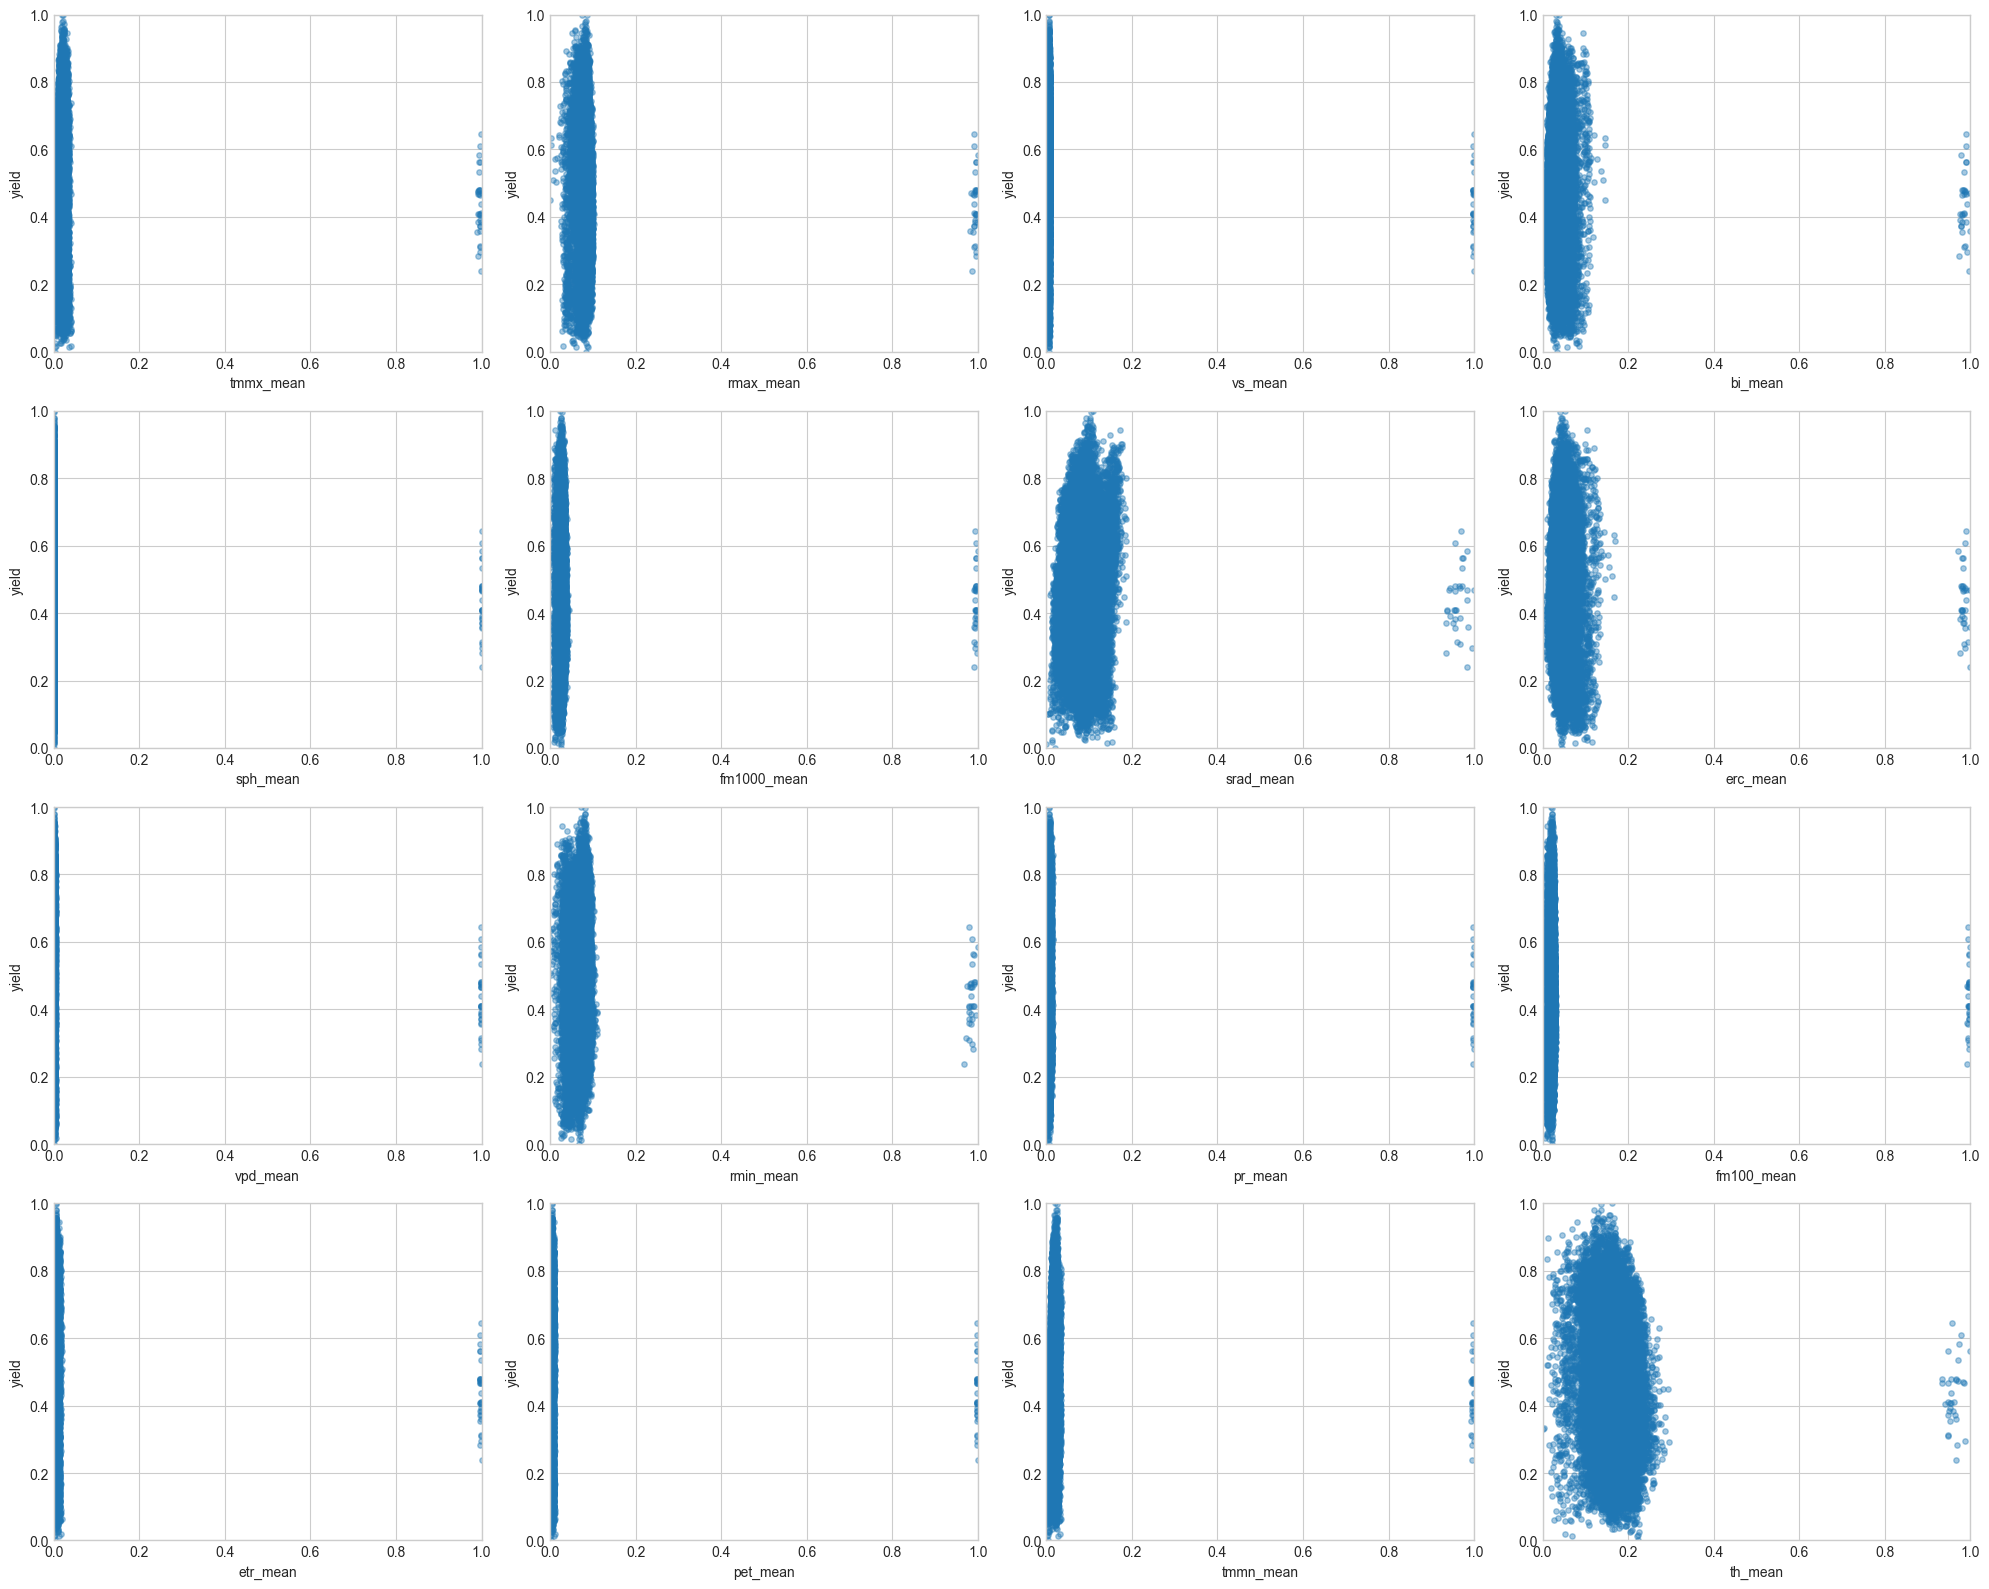


Count of points > 0.8 for each variable:
tmmx_mean      :    33 (  0.1%)
rmax_mean      :    33 (  0.1%)
vs_mean        :    33 (  0.1%)
bi_mean        :    33 (  0.1%)
sph_mean       :    33 (  0.1%)
fm1000_mean    :    33 (  0.1%)
srad_mean      :    33 (  0.1%)
erc_mean       :    33 (  0.1%)
vpd_mean       :    33 (  0.1%)
rmin_mean      :    33 (  0.1%)
pr_mean        :    33 (  0.1%)
fm100_mean     :    33 (  0.1%)
etr_mean       :    33 (  0.1%)
pet_mean       :    33 (  0.1%)
tmmn_mean      :    33 (  0.1%)
th_mean        :    33 (  0.1%)

yield          :   748 (  1.8%)


In [237]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Normalize 
met_vars = ['tmmx_mean', 'rmax_mean', 'vs_mean', 'bi_mean', 'sph_mean', 
            'fm1000_mean', 'srad_mean', 'erc_mean', 'vpd_mean', 'rmin_mean', 
            'pr_mean', 'fm100_mean', 'etr_mean', 'pet_mean', 'tmmn_mean', 'th_mean']
target = 'yield'

gridmet_normalized = gridmet_aug.copy()
normalizer = MinMaxScaler(feature_range=(0, 1))
gridmet_normalized[met_vars + [target]] = normalizer.fit_transform(gridmet_aug[met_vars + [target]])

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, var in enumerate(met_vars):
    axes[i].scatter(gridmet_normalized[var], gridmet_normalized[target], alpha=0.4, s=15)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('yield')
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Print summary
print("\nCount of points > 0.8 for each variable:")
print("="*50)

for var in met_vars:
    count = (gridmet_normalized[var] > 0.8).sum()
    pct = 100 * count / len(gridmet_normalized)
    print(f"{var:15s}: {count:5d} ({pct:5.1f}%)")

# Also for yield
count_yield = (gridmet_normalized[target] > 0.8).sum()
pct_yield = 100 * count_yield / len(gridmet_normalized)
print(f"\n{target:15s}: {count_yield:5d} ({pct_yield:5.1f}%)")

In [238]:
high_value_masks = {}
for var in met_vars:
    high_value_masks[var] = gridmet_normalized[var] > 0.8

high_rows = gridmet_normalized[high_value_masks[met_vars[0]]]
print(high_rows[['id2', 'year']].to_string())

        id2  year
1200   3066  1983
2485   3066  1984
3765   3066  1985
5030   3066  1986
6288   3066  1987
7544   3066  1988
8798   3066  1989
10025  3066  1990
11266  3066  1991
12510  3066  1992
13725  3066  1993
14949  3066  1994
16148  3066  1995
17340  3066  1996
18518  3066  1997
19704  3066  1998
20866  3066  1999
22025  3066  2000
23171  3066  2001
24330  3066  2002
25485  3066  2003
26628  3066  2004
27771  3066  2005
28891  3066  2006
30022  3066  2007
31048  3066  2008
32099  3066  2009
33212  3066  2010
34289  3066  2011
35373  3066  2012
36370  3066  2013
37387  3066  2014
40345  3066  2017


### Scatterplot

Applies the initial filtering step for visualization (removing the known problematic county) before plotting transformed feature relationships.


In [248]:
# Remove rows with id2 = 3066
gridmet_aug = gridmet_aug[gridmet_aug['id2'] != 3066].copy()

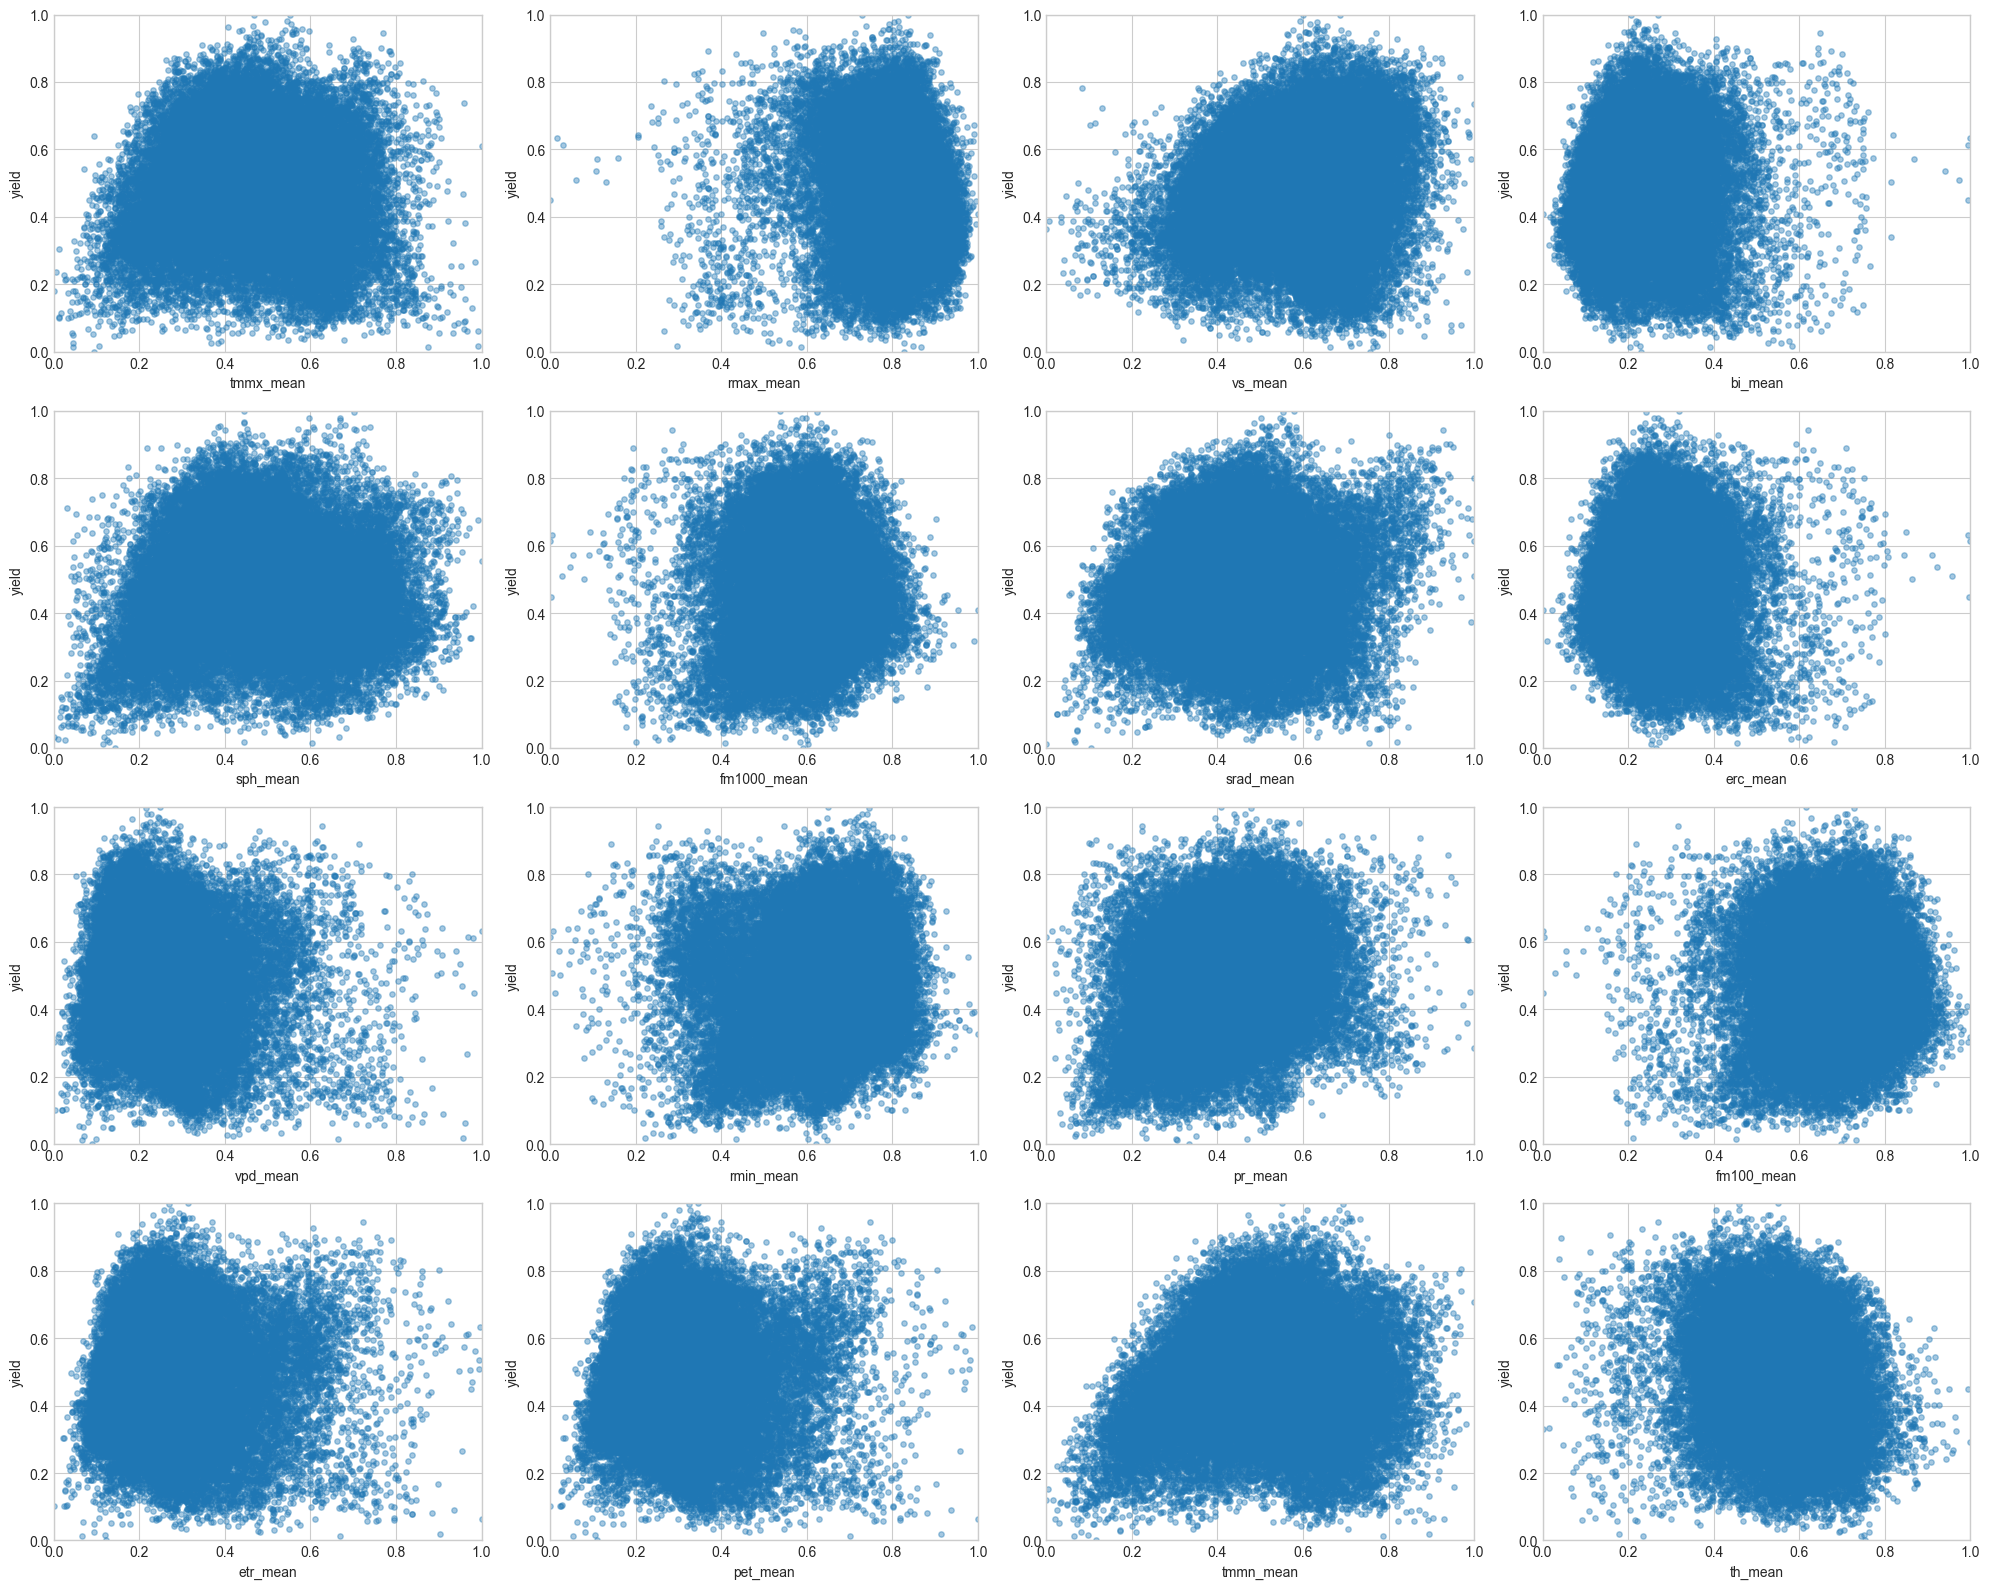

In [241]:
from sklearn.preprocessing import MinMaxScaler

# Normalize to [0, 1]
met_vars = ['tmmx_mean', 'rmax_mean', 'vs_mean', 'bi_mean', 'sph_mean', 
            'fm1000_mean', 'srad_mean', 'erc_mean', 'vpd_mean', 'rmin_mean', 
            'pr_mean', 'fm100_mean', 'etr_mean', 'pet_mean', 'tmmn_mean', 'th_mean']
target = 'yield'

gridmet_normalized = gridmet_aug.copy()
normalizer = MinMaxScaler(feature_range=(0, 1))
gridmet_normalized[met_vars + [target]] = normalizer.fit_transform(gridmet_filtered[met_vars + [target]])

# Create scatterplots
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, var in enumerate(met_vars):
    axes[i].scatter(gridmet_normalized[var], gridmet_normalized[target], alpha=0.4, s=15)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('yield')
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### PCA

Normalizes selected variables, reduces weather features with PCA, and visualizes principal-component structure against yield.


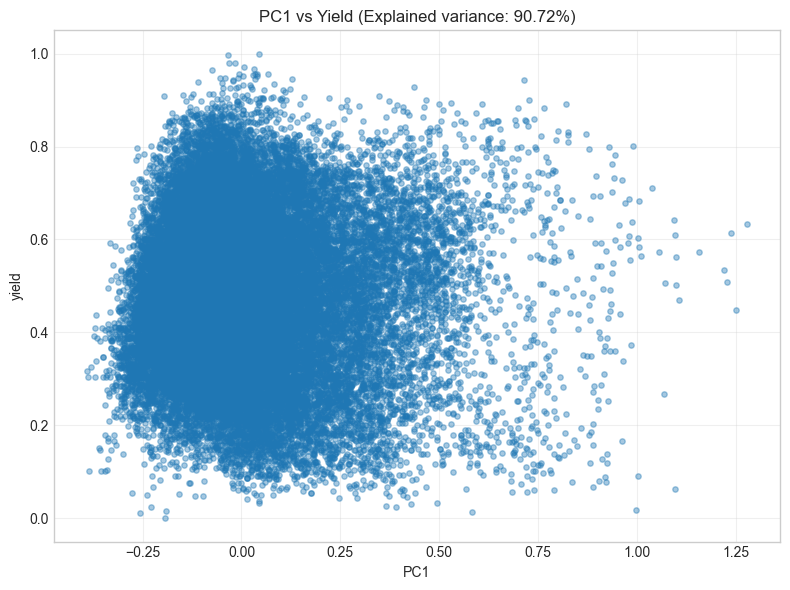

PC1 explained variance: 0.9072


In [249]:
from sklearn.decomposition import PCA

# Normalize to [0, 1]
met_vars = ['bi_mean', 'vpd_mean', 'etr_mean']
target = 'yield'

gridmet_normalized = gridmet_aug.copy()
normalizer = MinMaxScaler(feature_range=(0, 1))
gridmet_normalized[met_vars + [target]] = normalizer.fit_transform(gridmet_aug[met_vars + [target]])

pca = PCA(n_components=1)
pc1 = pca.fit_transform(gridmet_normalized[met_vars])

# Create single plot
plt.figure(figsize=(8, 6))
plt.scatter(pc1, gridmet_normalized[target], alpha=0.4, s=15)
plt.xlabel('PC1')
plt.ylabel('yield')
plt.title(f'PC1 vs Yield (Explained variance: {pca.explained_variance_ratio_[0]:.2%})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PC1 explained variance: {pca.explained_variance_ratio_[0]:.4f}")

## Categorized Yield

Creates yield-category/cluster analysis workflow to inspect structure in normalized feature space and compare subgroup behavior.


In [250]:
print(f"Min yield: {gridmet_aug['yield'].min()}, Max yield: {gridmet_aug['yield'].max()}")

Min yield: 7.0, Max yield: 246.7


In [251]:
train_data = gridmet_aug[gridmet_aug['year'] <= 2011].copy()
test_data = gridmet_aug[gridmet_aug['year'] == 2012].copy()

train_data['yield_category'] = None
years = sorted(train_data['year'].unique())

# Categorize each year based on historical average
for i, year in enumerate(years[1:], 1):  # Skip first year
    historical_avg = train_data[train_data['year'] < year]['yield'].mean()
    current_mask = train_data['year'] == year
    yield_pct = (train_data.loc[current_mask, 'yield'] / historical_avg) * 100
    
    train_data.loc[current_mask, 'yield_category'] = pd.cut(
        yield_pct,
        bins=[-np.inf, 80, 100, 120, np.inf],
        labels=['Poor', 'Fair', 'Good', 'Excellent']
    )

print(f"Train: {len(train_data)} rows, Categorized: {train_data['yield_category'].notna().sum()}")
print(train_data['yield_category'].value_counts().sort_index())

Train: 34307 rows, Categorized: 33052
yield_category
Excellent    15925
Fair          5513
Good          7266
Poor          4348
Name: count, dtype: int64


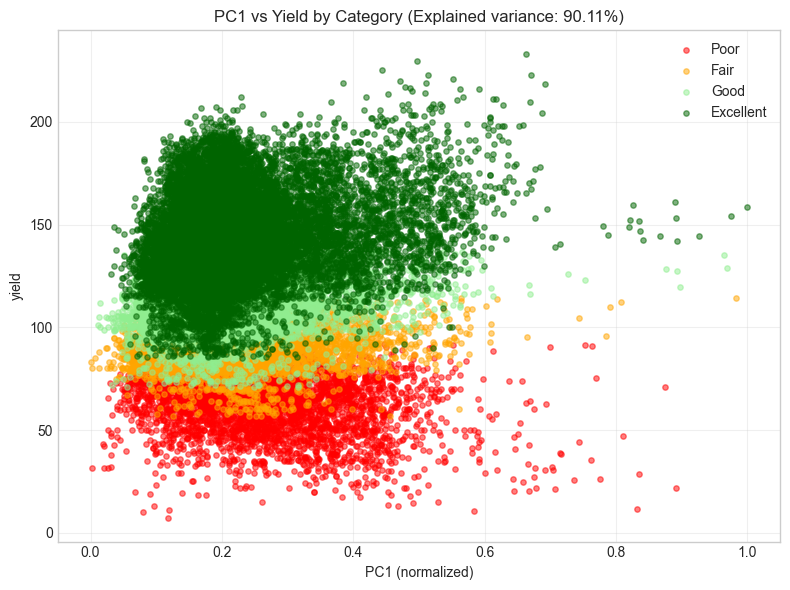

In [252]:
from sklearn.decomposition import PCA

train_categorized = train_data[train_data['yield_category'].notna()].copy()

normalizer = MinMaxScaler(feature_range=(0, 1))
train_normalized = normalizer.fit_transform(train_categorized[met_vars])

pca = PCA(n_components=1)
pc1 = pca.fit_transform(train_normalized)

# Normalize PC1
pc1_normalized = MinMaxScaler(feature_range=(0, 1)).fit_transform(pc1)

plt.figure(figsize=(8, 6))
colors = {'Poor': 'red', 'Fair': 'orange', 'Good': 'lightgreen', 'Excellent': 'darkgreen'}

for category in ['Poor', 'Fair', 'Good', 'Excellent']:
    mask = train_categorized['yield_category'] == category
    plt.scatter(pc1_normalized[mask], train_categorized.loc[mask, 'yield'], 
               alpha=0.5, s=15, c=colors[category], label=category)

plt.xlabel('PC1 (normalized)')
plt.ylabel('yield')
plt.title(f'PC1 vs Yield by Category (Explained variance: {pca.explained_variance_ratio_[0]:.2%})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

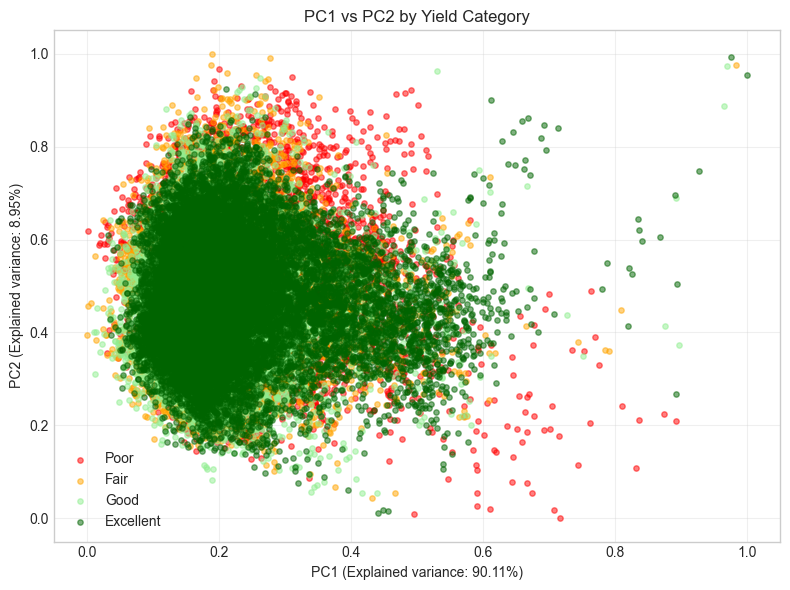

In [253]:
from sklearn.decomposition import PCA

train_categorized = train_data[train_data['yield_category'].notna()].copy()

normalizer = MinMaxScaler(feature_range=(0, 1))
train_normalized = normalizer.fit_transform(train_categorized[met_vars])

pca = PCA(n_components=2)
pcs = pca.fit_transform(train_normalized)

# Normalize PC1 and PC2
pc1_normalized = MinMaxScaler(feature_range=(0, 1)).fit_transform(pcs[:, 0].reshape(-1, 1))
pc2_normalized = MinMaxScaler(feature_range=(0, 1)).fit_transform(pcs[:, 1].reshape(-1, 1))

plt.figure(figsize=(8, 6))
colors = {'Poor': 'red', 'Fair': 'orange', 'Good': 'lightgreen', 'Excellent': 'darkgreen'}

for category in ['Poor', 'Fair', 'Good', 'Excellent']:
    mask = train_categorized['yield_category'] == category
    plt.scatter(pc1_normalized[mask], pc2_normalized[mask], 
               alpha=0.5, s=15, c=colors[category], label=category)

plt.xlabel(f'PC1 (Explained variance: {pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 (Explained variance: {pca.explained_variance_ratio_[1]:.2%})')
plt.title('PC1 vs PC2 by Yield Category')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

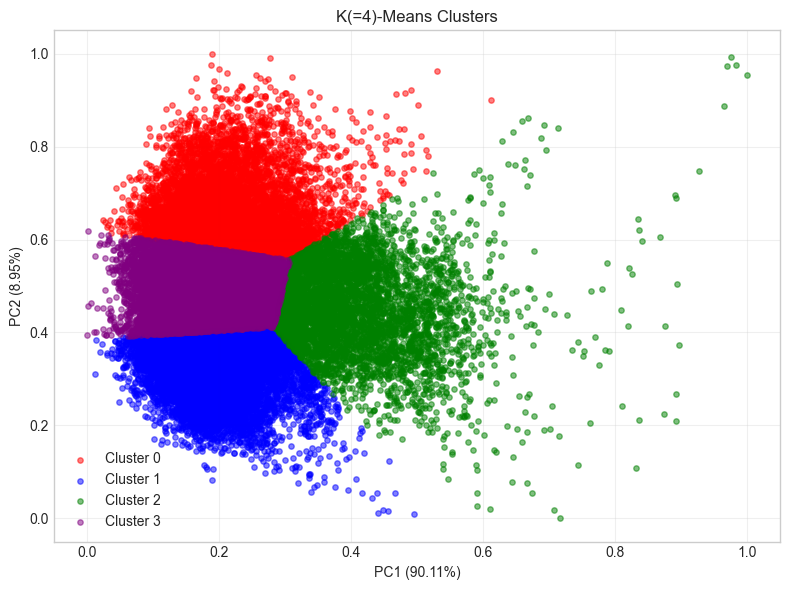

Cluster sizes: [ 6813 10208  4968 11063]


In [271]:
from sklearn.cluster import KMeans

train_categorized = train_data[train_data['yield_category'].notna()].copy()

normalizer = MinMaxScaler(feature_range=(0, 1))
train_normalized = normalizer.fit_transform(train_categorized[met_vars])

pca = PCA(n_components=2)
pcs = pca.fit_transform(train_normalized)

pc1_norm = MinMaxScaler(feature_range=(0, 1)).fit_transform(pcs[:, 0].reshape(-1, 1)).flatten()
pc2_norm = MinMaxScaler(feature_range=(0, 1)).fit_transform(pcs[:, 1].reshape(-1, 1)).flatten()

X_kmeans = np.column_stack([pc1_norm, pc2_norm])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_kmeans)

train_categorized['kmeans_cluster'] = clusters

plt.figure(figsize=(8, 6))
cluster_colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'purple'}

for cluster in range(4):
    mask = clusters == cluster
    plt.scatter(pc1_norm[mask], pc2_norm[mask], 
               alpha=0.5, s=15, c=cluster_colors[cluster], label=f'Cluster {cluster}')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('K(=4)-Means Clusters')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Cluster sizes:", np.bincount(clusters))

Training clusters: [ 6813 10208  4968 11063]
Test clusters: [153 194 664  75]


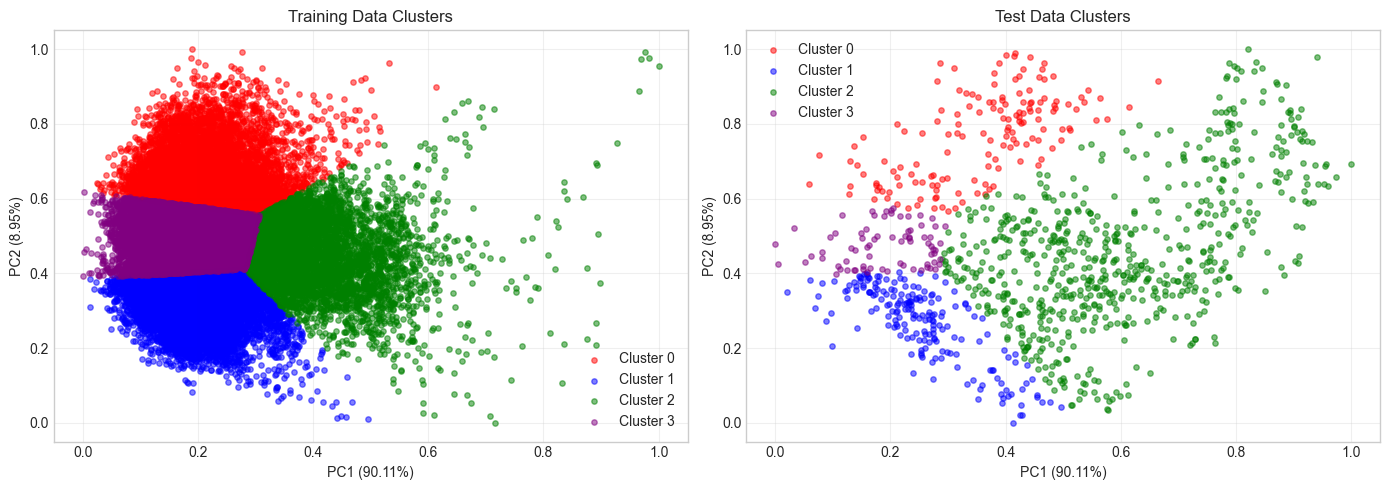

In [281]:
from sklearn.cluster import KMeans

train_categorized = train_data[train_data['yield_category'].notna()].copy()

normalizer = MinMaxScaler(feature_range=(0, 1))
train_normalized = normalizer.fit_transform(train_categorized[met_vars])

pca = PCA(n_components=2)
train_pcs = pca.fit_transform(train_normalized)

train_pc1_norm = MinMaxScaler(feature_range=(0, 1)).fit_transform(train_pcs[:, 0].reshape(-1, 1)).flatten()
train_pc2_norm = MinMaxScaler(feature_range=(0, 1)).fit_transform(train_pcs[:, 1].reshape(-1, 1)).flatten()

X_train_kmeans = np.column_stack([train_pc1_norm, train_pc2_norm])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_train_kmeans)

print(f"Training clusters: {np.bincount(kmeans.labels_)}")

# === TESTING ===
test_normalized = normalizer.transform(test_data[met_vars])
test_pcs = pca.transform(test_normalized)

test_pc1_norm = MinMaxScaler(feature_range=(0, 1)).fit_transform(test_pcs[:, 0].reshape(-1, 1)).flatten()
test_pc2_norm = MinMaxScaler(feature_range=(0, 1)).fit_transform(test_pcs[:, 1].reshape(-1, 1)).flatten()

X_test_kmeans = np.column_stack([test_pc1_norm, test_pc2_norm])
test_clusters = kmeans.predict(X_test_kmeans)

print(f"Test clusters: {np.bincount(test_clusters)}")

# === VISUALIZATION ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cluster_colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'purple'}

for cluster in range(4):
    mask = kmeans.labels_ == cluster
    axes[0].scatter(train_pc1_norm[mask], train_pc2_norm[mask], 
                   alpha=0.5, s=15, c=cluster_colors[cluster], label=f'Cluster {cluster}')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
axes[0].set_title('Training Data Clusters')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for cluster in range(4):
    mask = test_clusters == cluster
    axes[1].scatter(test_pc1_norm[mask], test_pc2_norm[mask], 
                   alpha=0.5, s=15, c=cluster_colors[cluster], label=f'Cluster {cluster}')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
axes[1].set_title('Test Data Clusters')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

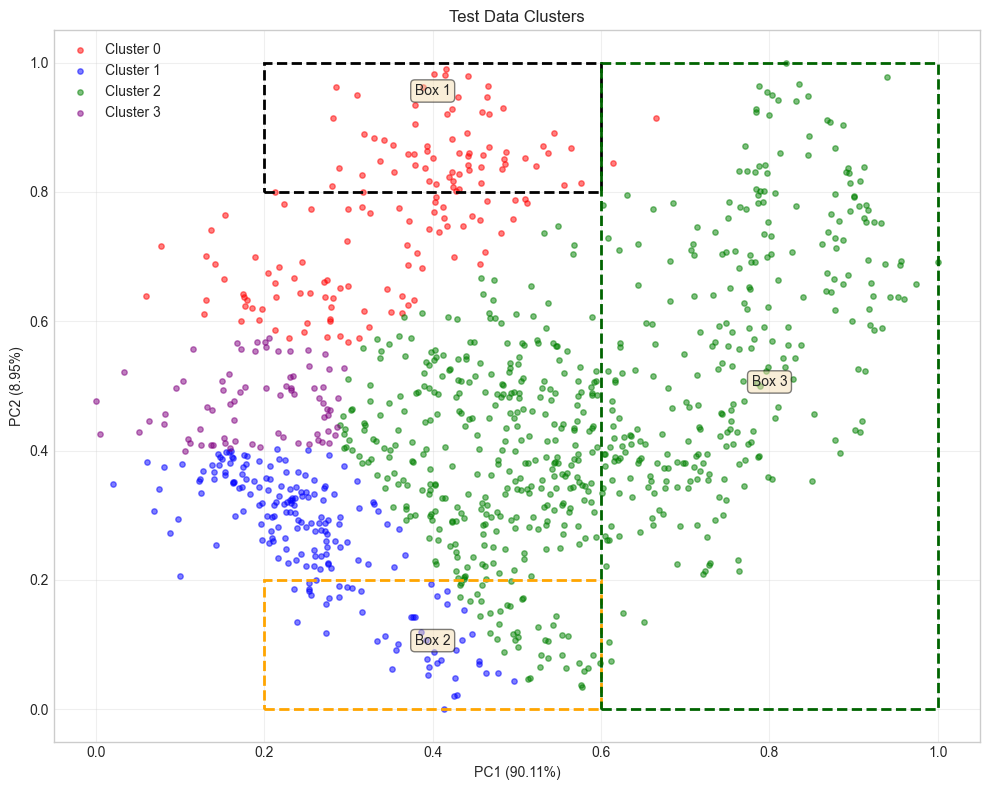

Total test points: 1086

Points in Box 1 [y:0.8-1.0, x:0.2-0.6]: 66 (6.1%)
Points in Box 2 [y:0.0-0.2, x:0.2-0.6]: 94 (8.7%)
Points in Box 3 [y:0.0-1.0, x:0.6-1.0]: 294 (27.1%)


In [278]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.figure(figsize=(10, 8))
cluster_colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'purple'}

# Plot all test clusters
for cluster in range(4):
    mask = test_clusters == cluster
    plt.scatter(test_pc1_norm[mask], test_pc2_norm[mask], 
               alpha=0.5, s=15, c=cluster_colors[cluster], label=f'Cluster {cluster}')

# Add bounding boxes
# Box 1: [y: 0.8-1.0, x: 0.2-0.6]
rect1 = Rectangle((0.2, 0.8), 0.4, 0.2, linewidth=2, edgecolor='black', facecolor='none', linestyle='--')
plt.gca().add_patch(rect1)
plt.text(0.4, 0.95, 'Box 1', ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Box 2: [y: 0.0-0.2, x: 0.2-0.6]
rect2 = Rectangle((0.2, 0.0), 0.4, 0.2, linewidth=2, edgecolor='orange', facecolor='none', linestyle='--')
plt.gca().add_patch(rect2)
plt.text(0.4, 0.1, 'Box 2', ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Box 3: [y: 0.0-1.0, x: 0.6-1.0]
rect3 = Rectangle((0.6, 0.0), 0.4, 1.0, linewidth=2, edgecolor='darkgreen', facecolor='none', linestyle='--')
plt.gca().add_patch(rect3)
plt.text(0.8, 0.5, 'Box 3', ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('Test Data Clusters')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

# Count points in each box
total_points = len(test_pc1_norm)
box1_count = box1_mask.sum()
box2_count = box2_mask.sum()
box3_count = box3_mask.sum()

print(f"Total test points: {total_points}")
print(f"\nPoints in Box 1 [y:0.8-1.0, x:0.2-0.6]: {box1_count} ({100*box1_count/total_points:.1f}%)")
print(f"Points in Box 2 [y:0.0-0.2, x:0.2-0.6]: {box2_count} ({100*box2_count/total_points:.1f}%)")
print(f"Points in Box 3 [y:0.0-1.0, x:0.6-1.0]: {box3_count} ({100*box3_count/total_points:.1f}%)")

In [274]:
train_categorized['cluster'] = kmeans.labels_
train_yield_stats = train_categorized.groupby('cluster')['yield'].agg(['mean', 'min', 'max'])
print("Training:")
print(train_yield_stats)

test_data_clustered = test_data.copy()
test_data_clustered['cluster'] = test_clusters
test_yield_stats = test_data_clustered.groupby('cluster')['yield'].agg(['mean', 'min', 'max'])
print("\nTest:")
print(test_yield_stats)

Training:
               mean   min    max
cluster                         
0        119.964054   7.0  212.0
1        108.005760  15.0  192.0
2        117.019344  10.4  233.2
3        124.345593  30.0  207.0

Test:
               mean   min    max
cluster                         
0        126.766013  41.7  186.3
1         87.034021  21.0  157.9
2        105.201506  19.0  206.6
3        125.925333  70.0  171.8


### Linear SVR using non-bounded box points

Trains/evaluates Linear SVR on points outside manually defined bounded regions in PCA space to test performance on cleaner subregions.


In [280]:
from sklearn.svm import LinearSVR

# Define boxes (points to EXCLUDE)
box1_mask = (test_pc1_norm >= 0.2) & (test_pc1_norm <= 0.6) & (test_pc2_norm >= 0.8) & (test_pc2_norm <= 1.0)
box2_mask = (test_pc1_norm >= 0.2) & (test_pc1_norm <= 0.6) & (test_pc2_norm >= 0.0) & (test_pc2_norm <= 0.2)
box3_mask = (test_pc1_norm >= 0.6) & (test_pc1_norm <= 1.0) & (test_pc2_norm >= 0.0) & (test_pc2_norm <= 1.0)

# Combined mask for all bounded boxes
bounded_mask = box1_mask | box2_mask | box3_mask
non_bounded_mask = ~bounded_mask

# Filter test data to only non-bounded points
test_data_non_bounded = test_data.iloc[non_bounded_mask].copy()

print(f"Total test points: {len(test_data)}")
print(f"Bounded points: {bounded_mask.sum()}")
print(f"Non-bounded points: {non_bounded_mask.sum()}\n")

# Prepare data
non_model_cols = ['yield', 'yield_category', 'cluster', 'kmeans_cluster']
X_train_raw = train_categorized.drop(columns=[col for col in non_model_cols if col in train_categorized.columns])
y_train = train_categorized['yield']
X_test_raw = test_data_non_bounded.drop(columns=[col for col in non_model_cols if col in test_data_non_bounded.columns])
y_test = test_data_non_bounded['yield']

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Linear SVR
svr_model = LinearSVR(C=10.0, epsilon=0.1, max_iter=5000, random_state=42)
svr_model.fit(X_train, y_train)
y_pred = svr_model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

pearson_r, _ = pearsonr(y_test, y_pred)
pearson_r2 = pearson_r**2

print("="*60)
print("LINEAR SVR RESULTS (NON-BOUNDED TEST POINTS)")
print("="*60)
print(f"Train samples: {len(X_train)}")
print(f"Test samples (non-bounded): {len(X_test)}")
print(f"\nR²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Pearson R²: {pearson_r2:.4f}")

Total test points: 1086
Bounded points: 454
Non-bounded points: 632

LINEAR SVR RESULTS (NON-BOUNDED TEST POINTS)
Train samples: 33052
Test samples (non-bounded): 632

R²: -0.1185
RMSE: 38.6079
MAE: 30.0963
Pearson R²: 0.2967


In [270]:
from sklearn.svm import LinearSVR

# Add cluster labels to train and test data
train_categorized['cluster'] = kmeans.labels_
test_data_clustered = test_data.copy()
test_data_clustered['cluster'] = test_clusters

# Prepare features
non_model_cols = ['yield', 'yield_category', 'cluster', 'kmeans_cluster']
results = []

print("="*80)
print("LINEAR SVR RESULTS BY CLUSTER")
print("="*80)

for cluster in range(8):
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster}")
    print(f"{'='*80}")
    
    # Filter train and test data for this cluster
    train_cluster = train_categorized[train_categorized['cluster'] == cluster]
    test_cluster = test_data_clustered[test_data_clustered['cluster'] == cluster]
    
    print(f"Train samples: {len(train_cluster)}, Test samples: {len(test_cluster)}")
    
    if len(test_cluster) == 0:
        print("No test samples in this cluster, skipping...")
        continue
    
    # Prepare data
    X_train_raw = train_cluster.drop(columns=[col for col in non_model_cols if col in train_cluster.columns])
    y_train = train_cluster['yield']
    X_test_raw = test_cluster.drop(columns=[col for col in non_model_cols if col in test_cluster.columns])
    y_test = test_cluster['yield']
    
    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)
    
    # Linear SVR
    svr_model = LinearSVR(C=10.0, epsilon=0.1, max_iter=5000, random_state=42)
    svr_model.fit(X_train, y_train)
    y_pred = svr_model.predict(X_test)
    
    # Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    bias = np.mean(y_pred - y_test)
    variance = np.var(y_pred - y_test)
    bias_squared = bias**2
    
    pearson_r, _ = pearsonr(y_test, y_pred)
    pearson_r2 = pearson_r**2
    
    print(f"  R²: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  Pearson R²: {pearson_r2:.4f}")
    
    results.append({
        'Cluster': cluster,
        'Train Size': len(train_cluster),
        'Test Size': len(test_cluster),
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae,
        'Pearson R²': pearson_r2
    })

print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

LINEAR SVR RESULTS BY CLUSTER

CLUSTER 0
Train samples: 2196, Test samples: 96
  R²: 0.6123
  RMSE: 19.6093
  MAE: 15.3325
  Pearson R²: 0.6334

CLUSTER 1
Train samples: 4324, Test samples: 88
  R²: -0.7539
  RMSE: 34.5768
  MAE: 27.2530
  Pearson R²: 0.2244

CLUSTER 2
Train samples: 6746, Test samples: 30
  R²: -0.3950
  RMSE: 29.7467
  MAE: 22.9493
  Pearson R²: 0.1832

CLUSTER 3
Train samples: 3241, Test samples: 147
  R²: 0.5820
  RMSE: 26.1394
  MAE: 21.4724
  Pearson R²: 0.6039

CLUSTER 4
Train samples: 5895, Test samples: 63
  R²: -0.8510
  RMSE: 29.9850
  MAE: 25.2864
  Pearson R²: 0.0389

CLUSTER 5
Train samples: 4622, Test samples: 31
  R²: -0.6807
  RMSE: 25.7347
  MAE: 21.4638
  Pearson R²: 0.4187

CLUSTER 6
Train samples: 4193, Test samples: 117
  R²: -2.5247
  RMSE: 50.6798
  MAE: 44.0623
  Pearson R²: 0.0105

CLUSTER 7
Train samples: 1835, Test samples: 514
  R²: 0.2994
  RMSE: 36.6031
  MAE: 28.3285
  Pearson R²: 0.4965

SUMMARY
 Cluster  Train Size  Test Size        R²

In [134]:
# Define threshold
high_threshold = 0.8

# Analyze each variable
print("="*80)
print("VARIABLES WITH VALUES > 0.8 AND THEIR CORRESPONDING YEARS AND ID2")
print("="*80)

for var in met_vars:
    high_mask = gridmet_normalized[var] > high_threshold
    
    if high_mask.sum() > 0:
        high_data = gridmet_normalized.loc[high_mask, ['id2', 'year']]
        
        print(f"\n{var}:")
        print(f"  Count: {high_mask.sum()} ({100*high_mask.sum()/len(gridmet_normalized):.1f}%)")
        print(f"  Years: {sorted(high_data['year'].unique().tolist())}")
        print(f"  ID2s: {sorted(high_data['id2'].unique().tolist())}")
        print(f"  Year-ID2 combinations:")
        for _, row in high_data.iterrows():
            print(f"    Year: {row['year']}, ID2: {row['id2']}")
    else:
        print(f"\n{var}: No values > {high_threshold}")

# Also check yield
print("\n" + "="*80)
high_yield_mask = gridmet_normalized[target] > high_threshold

if high_yield_mask.sum() > 0:
    high_yield_data = gridmet_normalized.loc[high_yield_mask, ['id2', 'year']]
    
    print(f"\n{target}:")
    print(f"  Count: {high_yield_mask.sum()} ({100*high_yield_mask.sum()/len(gridmet_normalized):.1f}%)")
    print(f"  Years: {sorted(high_yield_data['year'].unique().tolist())}")
    print(f"  ID2s: {sorted(high_yield_data['id2'].unique().tolist())}")
    print(f"  Year-ID2 combinations:")
    for _, row in high_yield_data.iterrows():
        print(f"    Year: {row['year']}, ID2: {row['id2']}")
else:
    print(f"\n{target}: No values > {high_threshold}")

VARIABLES WITH VALUES > 0.8 AND THEIR CORRESPONDING YEARS AND ID2

tmmx_mean:
  Count: 33 (0.1%)
  Years: [1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2017]
  ID2s: [3066]
  Year-ID2 combinations:
    Year: 1983, ID2: 3066
    Year: 1984, ID2: 3066
    Year: 1985, ID2: 3066
    Year: 1986, ID2: 3066
    Year: 1987, ID2: 3066
    Year: 1988, ID2: 3066
    Year: 1989, ID2: 3066
    Year: 1990, ID2: 3066
    Year: 1991, ID2: 3066
    Year: 1992, ID2: 3066
    Year: 1993, ID2: 3066
    Year: 1994, ID2: 3066
    Year: 1995, ID2: 3066
    Year: 1996, ID2: 3066
    Year: 1997, ID2: 3066
    Year: 1998, ID2: 3066
    Year: 1999, ID2: 3066
    Year: 2000, ID2: 3066
    Year: 2001, ID2: 3066
    Year: 2002, ID2: 3066
    Year: 2003, ID2: 3066
    Year: 2004, ID2: 3066
    Year: 2005, ID2: 3066
    Year: 2006, ID2: 3066
    Year: 2007, ID2: 3066
    Y

## Before 2012

Builds a pre-2012 normalization and projection view for exploratory analysis of how weather-feature geometry evolves before the 2012 shift.


Original data: 41267 rows
After removing id2=3066: 41234 rows
Removed: 33 rows

Data before 2012: 34307 rows
Years included: [1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011]



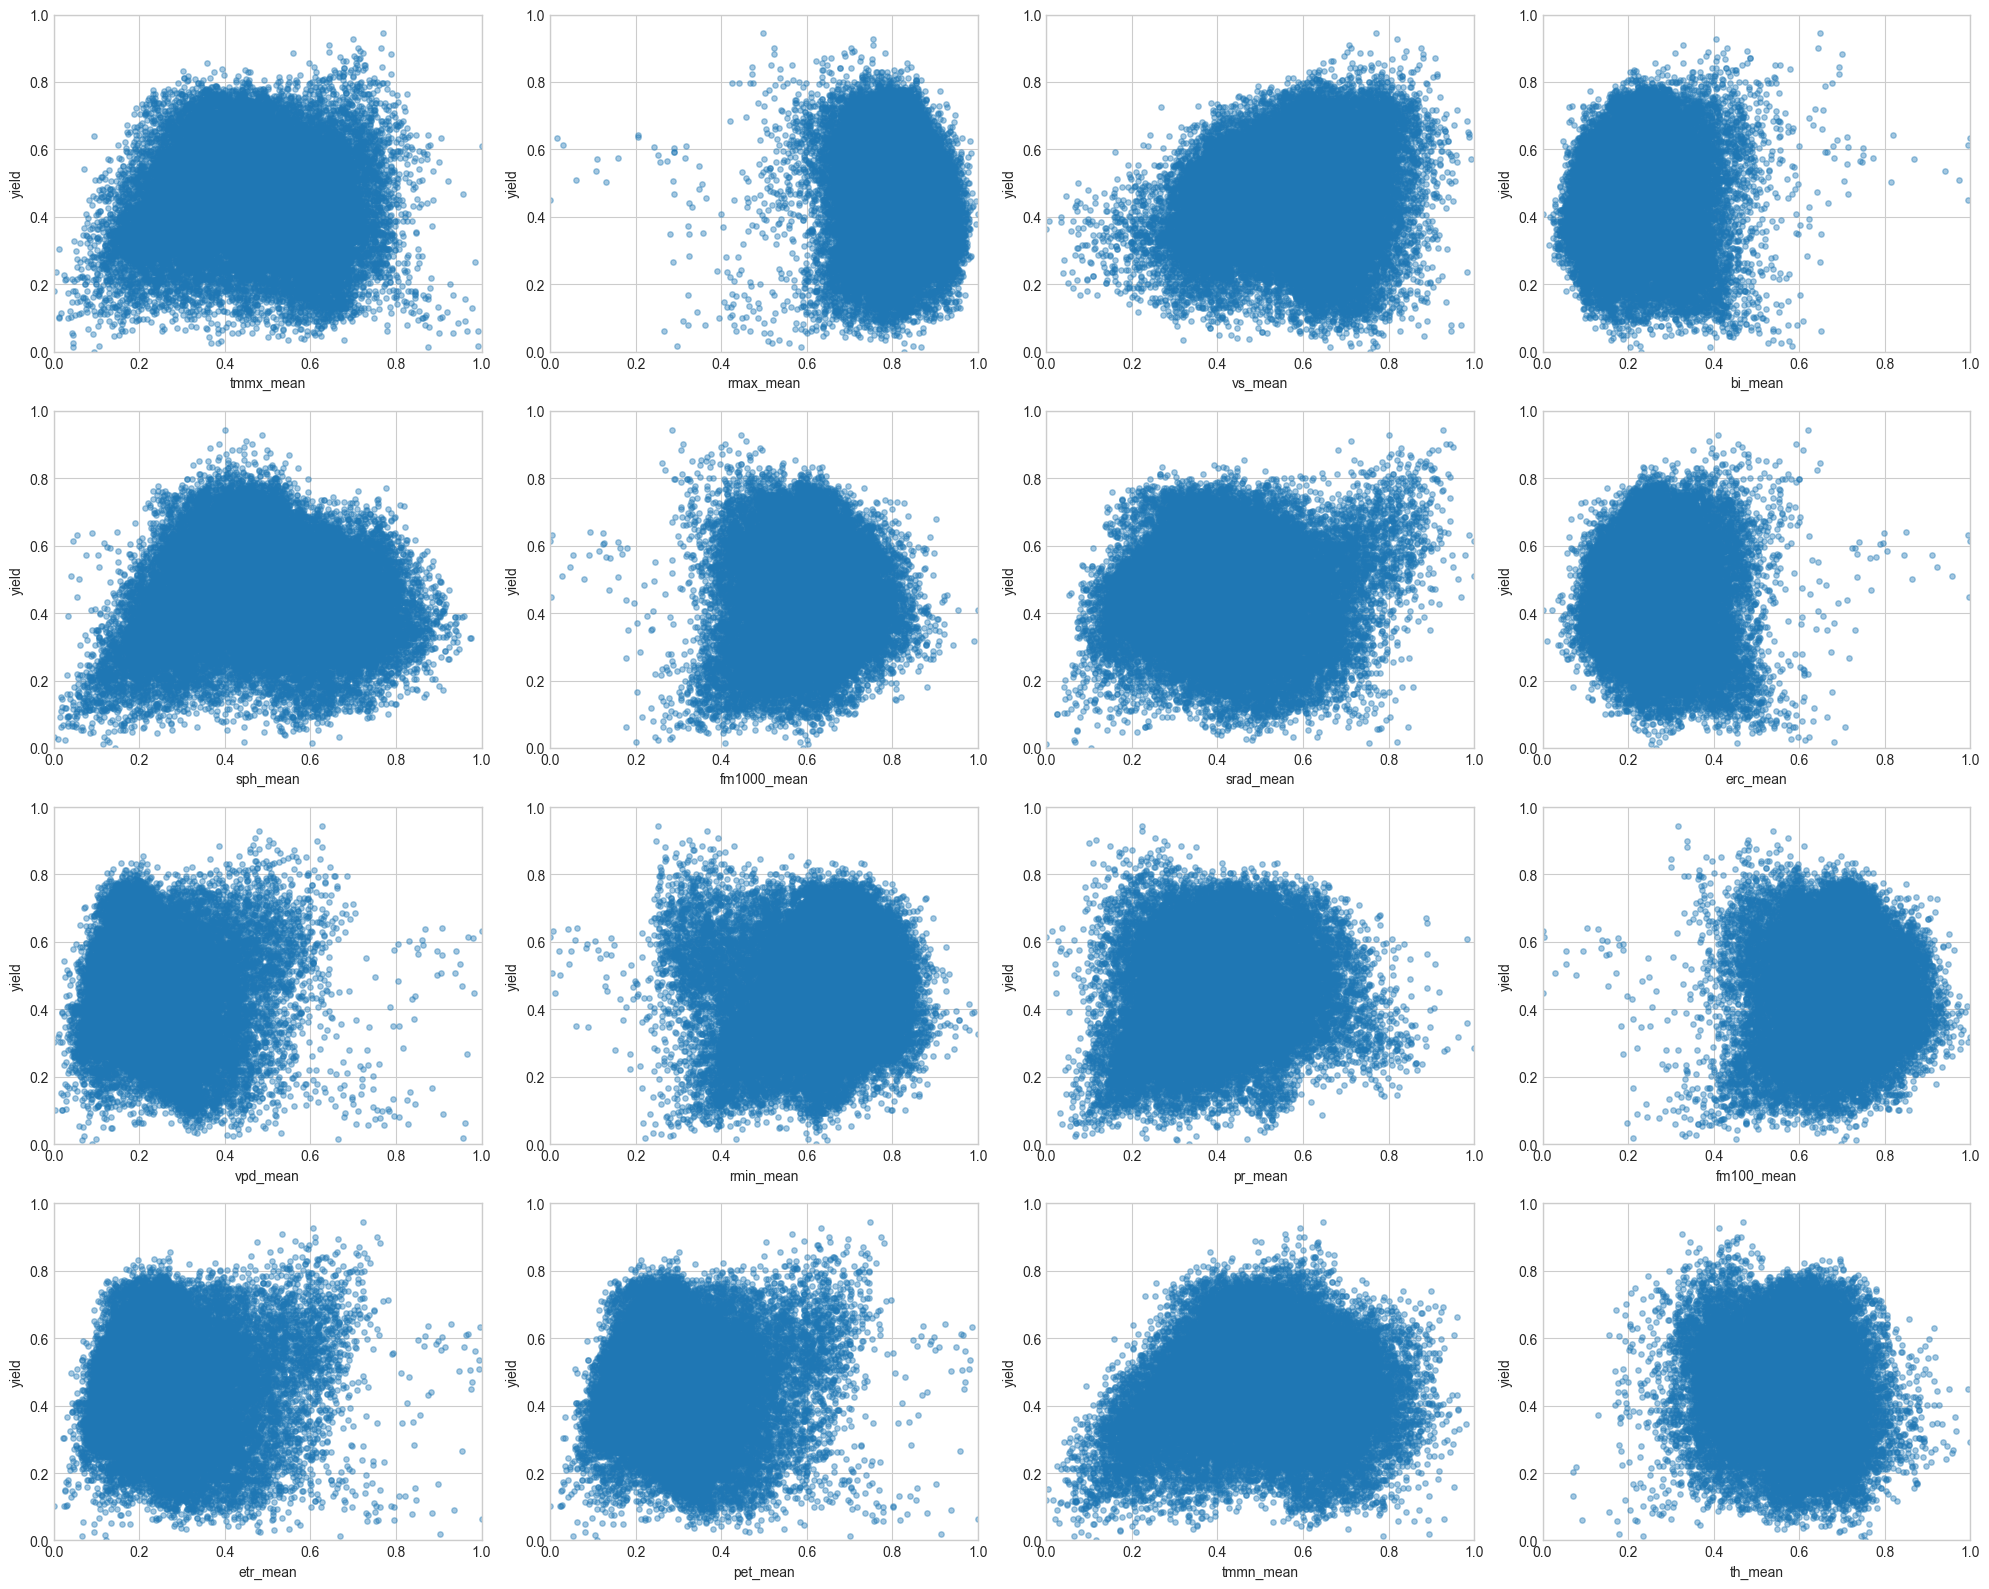


Count of points > 0.8 for each variable (before 2012):
tmmx_mean      :   167 (  0.5%)
rmax_mean      : 19419 ( 56.6%)
vs_mean        :  1296 (  3.8%)
bi_mean        :     8 (  0.0%)
sph_mean       :   734 (  2.1%)
fm1000_mean    :   475 (  1.4%)
srad_mean      :   437 (  1.3%)
erc_mean       :    10 (  0.0%)
vpd_mean       :    36 (  0.1%)
rmin_mean      :  1728 (  5.0%)
pr_mean        :    98 (  0.3%)
fm100_mean     :  4560 ( 13.3%)
etr_mean       :    41 (  0.1%)
pet_mean       :    45 (  0.1%)
tmmn_mean      :   770 (  2.2%)
th_mean        :   302 (  0.9%)

yield          :    93 (  0.3%)


In [166]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Remove rows with id2 = 3066
gridmet_filtered = gridmet_aug[gridmet_aug['id2'] != 3066].copy()

print(f"Original data: {len(gridmet_aug)} rows")
print(f"After removing id2=3066: {len(gridmet_filtered)} rows")
print(f"Removed: {len(gridmet_aug) - len(gridmet_filtered)} rows\n")

# Normalize to [0, 1]
met_vars = ['tmmx_mean', 'rmax_mean', 'vs_mean', 'bi_mean', 'sph_mean', 
            'fm1000_mean', 'srad_mean', 'erc_mean', 'vpd_mean', 'rmin_mean', 
            'pr_mean', 'fm100_mean', 'etr_mean', 'pet_mean', 'tmmn_mean', 'th_mean']
target = 'yield'

gridmet_normalized = gridmet_filtered.copy()
normalizer = MinMaxScaler(feature_range=(0, 1))
gridmet_normalized[met_vars + [target]] = normalizer.fit_transform(gridmet_filtered[met_vars + [target]])

# Filter for years before 2012
gridmet_before_2012 = gridmet_normalized[gridmet_normalized['year'] < 2012]

print(f"Data before 2012: {len(gridmet_before_2012)} rows")
print(f"Years included: {sorted(gridmet_before_2012['year'].unique())}\n")

# Create scatterplots
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, var in enumerate(met_vars):
    axes[i].scatter(gridmet_before_2012[var], gridmet_before_2012[target], alpha=0.4, s=15)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('yield')
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Print summary
print("\nCount of points > 0.8 for each variable (before 2012):")
print("="*50)
for var in met_vars:
    count = (gridmet_before_2012[var] > 0.8).sum()
    pct = 100 * count / len(gridmet_before_2012)
    print(f"{var:15s}: {count:5d} ({pct:5.1f}%)")

# Also for yield
count_yield = (gridmet_before_2012[target] > 0.8).sum()
pct_yield = 100 * count_yield / len(gridmet_before_2012)
print(f"\n{target:15s}: {count_yield:5d} ({pct_yield:5.1f}%)")

Original data: 41267 rows
After removing id2=3066: 41234 rows
Removed: 33 rows

Data for year 2012: 1086 rows



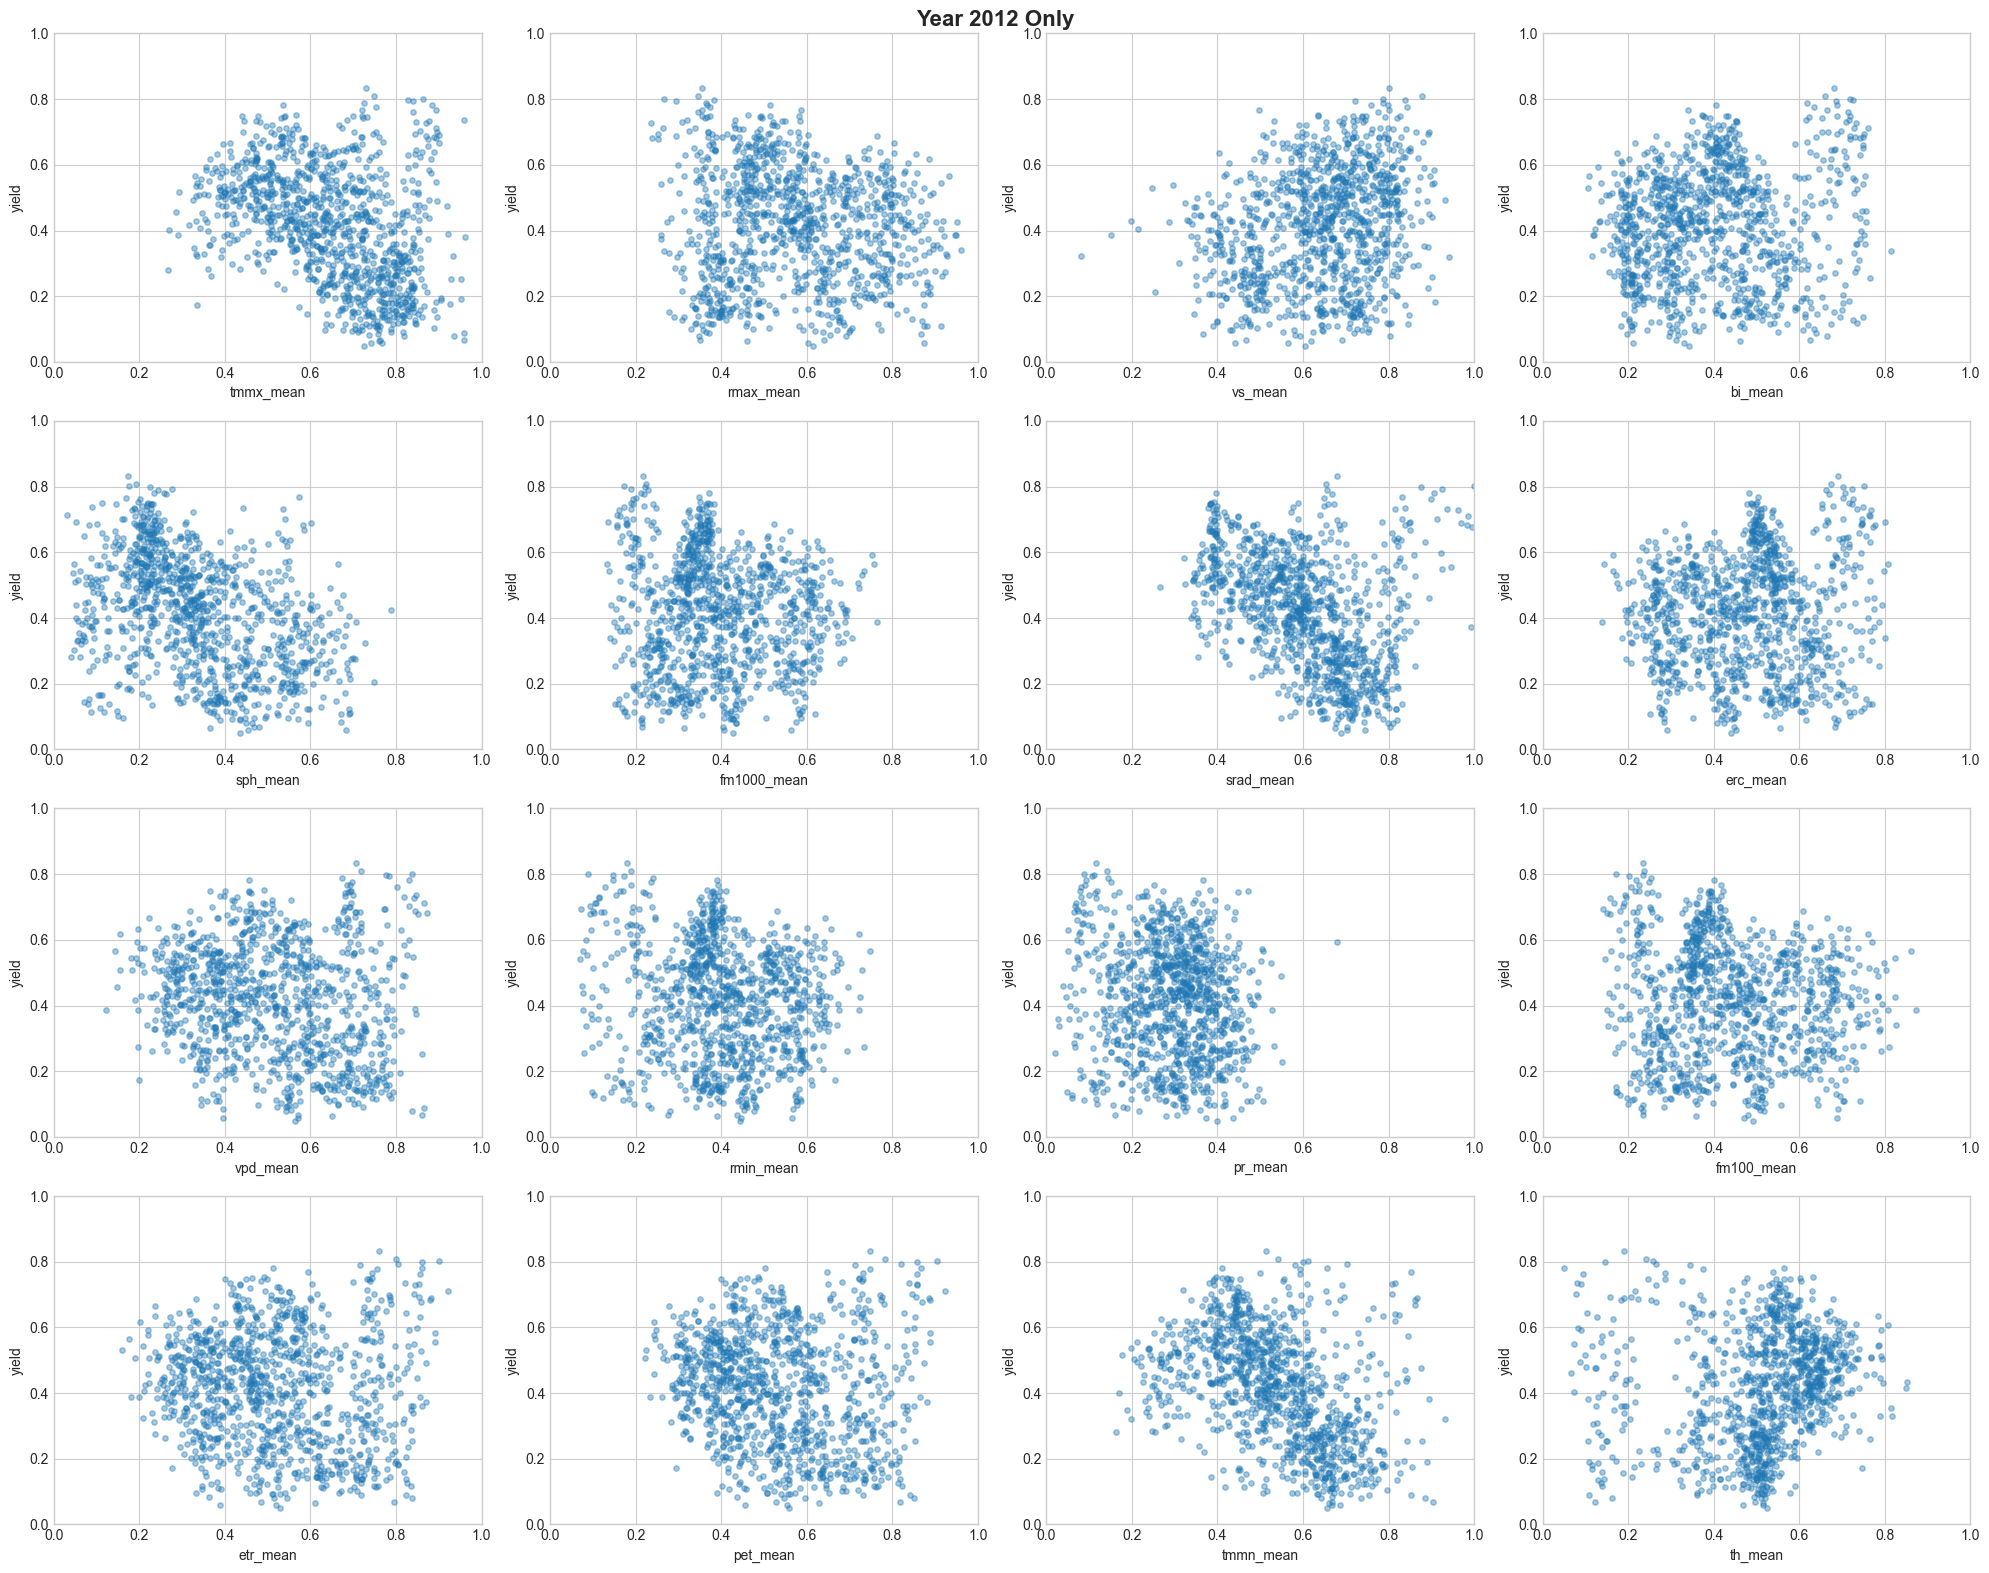


Count of points > 0.8 for each variable (2012 only):
tmmx_mean      :   175 ( 16.1%)
rmax_mean      :   101 (  9.3%)
vs_mean        :   117 ( 10.8%)
bi_mean        :     1 (  0.1%)
sph_mean       :     0 (  0.0%)
fm1000_mean    :     0 (  0.0%)
srad_mean      :    80 (  7.4%)
erc_mean       :     2 (  0.2%)
vpd_mean       :    27 (  2.5%)
rmin_mean      :     0 (  0.0%)
pr_mean        :     0 (  0.0%)
fm100_mean     :     8 (  0.7%)
etr_mean       :    53 (  4.9%)
pet_mean       :    54 (  5.0%)
tmmn_mean      :    31 (  2.9%)
th_mean        :     5 (  0.5%)

yield          :     3 (  0.3%)


In [167]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Remove rows with id2 = 3066
gridmet_filtered = gridmet_aug[gridmet_aug['id2'] != 3066].copy()

print(f"Original data: {len(gridmet_aug)} rows")
print(f"After removing id2=3066: {len(gridmet_filtered)} rows")
print(f"Removed: {len(gridmet_aug) - len(gridmet_filtered)} rows\n")

# Normalize to [0, 1]
met_vars = ['tmmx_mean', 'rmax_mean', 'vs_mean', 'bi_mean', 'sph_mean', 
            'fm1000_mean', 'srad_mean', 'erc_mean', 'vpd_mean', 'rmin_mean', 
            'pr_mean', 'fm100_mean', 'etr_mean', 'pet_mean', 'tmmn_mean', 'th_mean']
target = 'yield'

gridmet_normalized = gridmet_filtered.copy()
normalizer = MinMaxScaler(feature_range=(0, 1))
gridmet_normalized[met_vars + [target]] = normalizer.fit_transform(gridmet_filtered[met_vars + [target]])

# Filter for year 2012 only
gridmet_2012 = gridmet_normalized[gridmet_normalized['year'] == 2012]

print(f"Data for year 2012: {len(gridmet_2012)} rows\n")

# Create scatterplots
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, var in enumerate(met_vars):
    axes[i].scatter(gridmet_2012[var], gridmet_2012[target], alpha=0.4, s=15)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('yield')
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)

plt.suptitle('Year 2012 Only', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
print("\nCount of points > 0.8 for each variable (2012 only):")
print("="*50)
for var in met_vars:
    count = (gridmet_2012[var] > 0.8).sum()
    pct = 100 * count / len(gridmet_2012) if len(gridmet_2012) > 0 else 0
    print(f"{var:15s}: {count:5d} ({pct:5.1f}%)")

# Also for yield
count_yield = (gridmet_2012[target] > 0.8).sum()
pct_yield = 100 * count_yield / len(gridmet_2012) if len(gridmet_2012) > 0 else 0
print(f"\n{target:15s}: {count_yield:5d} ({pct_yield:5.1f}%)")